# Import

In [1]:
# 나눔폰트 설치 (Linux 명령어)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

from xgboost import XGBRegressor

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# Data Load 및 정보확인

In [3]:
!pip install gdown -q
import gdown

FILE_IDS = {
    'train.csv': '1Ec0bpYkjUGjNOV5ys8L0z0R1Y--MrjFY',
    'test.csv': '1tcPVxWOtHnqYUy3uhiFrOkHkQCp2V175',
    'sample_submission.csv' : '1Oc579A8DImPn5cF7Pk7ujr_WosK5pi7_',
    'data_spec.xlsx' : '1MyinOD1CYxcce8h4xURzTWO-lFcFk_oA',
}

for fname, file_id in FILE_IDS.items():
    gdown.download(f'https://drive.google.com/uc?id={file_id}', fname, quiet=False)

train = pd.read_csv('train.csv', encoding='utf-8-sig')
test = pd.read_csv('test.csv', encoding='utf-8-sig')
submission = pd.read_csv('sample_submission.csv', encoding='utf-8-sig')
data_spec = pd.read_excel('data_spec.xlsx')

target = '임신 성공 여부'
print(train.shape, test.shape)


Downloading...
From: https://drive.google.com/uc?id=1Ec0bpYkjUGjNOV5ys8L0z0R1Y--MrjFY
To: /content/train.csv
100%|██████████| 84.1M/84.1M [00:00<00:00, 149MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tcPVxWOtHnqYUy3uhiFrOkHkQCp2V175
To: /content/test.csv
100%|██████████| 29.2M/29.2M [00:00<00:00, 93.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Oc579A8DImPn5cF7Pk7ujr_WosK5pi7_
To: /content/sample_submission.csv
100%|██████████| 1.35M/1.35M [00:00<00:00, 139MB/s]
Downloading...
From: https://drive.google.com/uc?id=1MyinOD1CYxcce8h4xURzTWO-lFcFk_oA
To: /content/data_spec.xlsx
100%|██████████| 16.9k/16.9k [00:00<00:00, 10.3MB/s]


(256351, 69) (90067, 68)


In [4]:
train.shape, test.shape, submission.shape

((256351, 69), (90067, 68), (90067, 2))

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 부 불임 원인             256351 non-nu

In [6]:
train.head(10)

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
5,TRAIN_000005,TRVNRY,만38-39세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
6,TRAIN_000006,TRJXFG,만18-34세,NaN,IVF,ICSI,0,알 수 없음,1.0,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2.0,NaN,0
7,TRAIN_000007,TRXQMD,만40-42세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,5.0,NaN,0
8,TRAIN_000008,TRYBLT,만38-39세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0
9,TRAIN_000009,TRYBLT,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [7]:
train.describe()

,임신 시도 또는 마지막 임신 경과 연수,배란 자극 여부,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,착상 전 유전 진단 사용 여부,남성 주 불임 원인,남성 부 불임 원인,여성 주 불임 원인,여성 부 불임 원인,부부 주 불임 원인,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
count,9370.000000,256351.000000,250060.000000,2718.0,250060.000000,256351.000000,256351.000000,256351.000000,256351.000000,256351.000000,...,250060.000000,250060.000000,2179.0,1929.0,198863.0,1436.000000,202616.000000,212785.000000,40369.000000,256351.000000
mean,9.270651,0.771286,0.233476,1.0,0.012781,0.028516,0.013115,0.030724,0.012432,0.033068,...,0.009830,0.004195,1.0,1.0,0.0,0.001393,0.005385,3.254741,0.045629,0.258349
std,3.550313,0.420005,0.423043,0.0,0.112328,0.166441,0.113767,0.172568,0.110805,0.178814,...,0.098656,0.064633,0.0,0.0,0.0,0.037307,0.111504,1.715697,0.418672,0.437728
min,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
50%,9.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,3.000000,0.000000,0.000000
75%,11.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.0,1.0,0.0,0.000000,0.000000,5.000000,0.000000,1.000000
max,20.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.0,1.0,0.0,1.000000,7.000000,7.000000,7.000000,1.000000


In [8]:
target_counts = train['임신 성공 여부'].value_counts()
target_ratio = train['임신 성공 여부'].value_counts(normalize=True)

print(f"임신 성공 여부 [0] 실패 = {target_counts[0]:,} ({round(target_ratio[0]*100,2)}%)")
print(f"            [1] 성공 =  {target_counts[1]:,} ({round(target_ratio[1]*100,2)}%)")

임신 성공 여부 [0] 실패 = 190,123 (74.17%)
            [1] 성공 =  66,228 (25.83%)


In [9]:
X_train = train.drop(columns=["ID","임신 성공 여부"])
y_train = train["임신 성공 여부"]

X_test = test.drop(columns = ['ID']).copy()

In [10]:
# 전체 컬럼별 결측치 개수 및 비율 계산
missing_counts = train.isnull().sum()
missing_ratios = (train.isnull().sum() / len(train)) * 100
missing_total  = (missing_counts > 0).sum()

# 데이터프레임으로 결합 > 결측치 높은순(내림차순)
missing_df = pd.DataFrame({
    '결측치 개수': missing_counts,
    '결측치 비율(%)': missing_ratios
}).sort_values(by='결측치 비율(%)', ascending=False)

# 결측치가 1개라도 있는 컬럼 전체 출력
print(f"[ ⚠️ 결측치 발생 컬럼 ]")
print(f"\n* total : {missing_total} 개 컬럼")
print(f"\n* ranking")
display(missing_df[missing_df['결측치 개수'] > 0])

[ ⚠️ 결측치 발생 컬럼 ]

* total : 31 개 컬럼

* ranking


,결측치 개수,결측치 비율(%)
난자 해동 경과일,254915,99.439831
PGS 시술 여부,254422,99.247516
PGD 시술 여부,254172,99.149994
착상 전 유전 검사 사용 여부,253633,98.939735
임신 시도 또는 마지막 임신 경과 연수,246981,96.344855
배아 해동 경과일,215982,84.252451
난자 채취 경과일,57488,22.425503
난자 혼합 경과일,53735,20.961494
배아 이식 경과일,43566,16.994667
미세주입 후 저장된 배아 수,6291,2.454057


# <font color="darkgreen">[1단계] EDA 및 결측 구조 파악</font>

## 🔍 카테고리별 성공률

In [11]:
# 데이터 명세 엑셀에서 '범주형 여부'= 1 인 컬럼 리스트 만들기
cat_cols = data_spec.loc[data_spec['범주형 여부'] == 1, '컬럼명'].tolist()
num_cols = data_spec.loc[data_spec['범주형 여부'] == 0, '컬럼명'].tolist()

# spec 컬럼명 vs train 컬럼명 표기가 다를 수 있으니 교집합만 사용
cat_cols = [c for c in cat_cols if c in train.columns]
num_cols = [c for c in num_cols if c in train.columns]

## 🔍 수치형 변수 상관관계

In [12]:
corr = train[num_cols + [y_train.name]].corr()[target].sort_values(ascending=False)
print(corr)

임신 성공 여부                 1.000000
이식된 배아 수                 0.157487
배아 이식 경과일                0.148590
총 생성 배아 수                0.146116
혼합된 난자 수                 0.116136
파트너 정자와 혼합된 난자 수         0.104902
미세주입에서 생성된 배아 수          0.090275
수집된 신선 난자 수              0.083023
미세주입 배아 이식 수             0.074351
미세주입된 난자 수               0.070117
저장된 배아 수                 0.036024
기증자 정자와 혼합된 난자 수         0.026181
미세주입 후 저장된 배아 수          0.021737
해동 난자 수                 -0.002147
난자 혼합 경과일               -0.008600
해동된 배아 수                -0.014906
배아 해동 경과일               -0.017346
난자 해동 경과일               -0.019958
저장된 신선 난자 수             -0.047763
임신 시도 또는 마지막 임신 경과 연수   -0.051925
난자 채취 경과일                     NaN
Name: 임신 성공 여부, dtype: float64


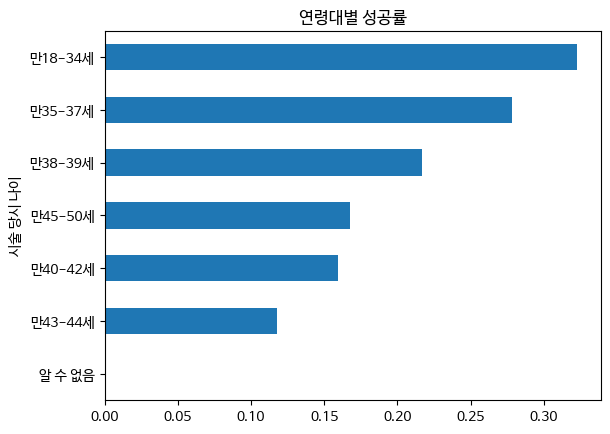

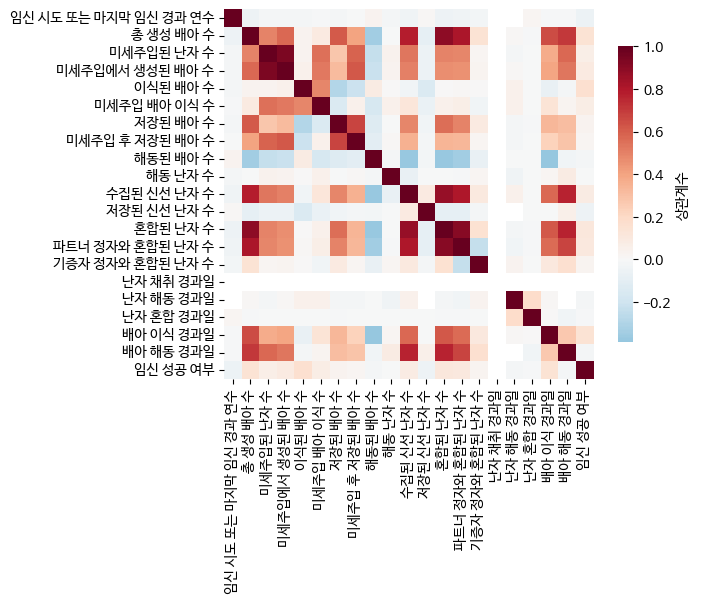

In [13]:
import matplotlib.pyplot as plt

# 카테고리별 성공률 막대그래프 예시
train.groupby('시술 당시 나이')[target].mean().sort_values().plot(kind='barh')
plt.title('연령대별 성공률')
plt.show()

# 수치형 상관관계 히트맵
import seaborn as sns
sns.heatmap(
            train[num_cols + [target]].corr(),
            # annot=True,       # 숫자 표시
            cmap='RdBu_r',    # 빨강-파랑 색상맵
            center=0,         # 0 중심 색상
            square=True,      # 정사각형 셀
            fmt='.2f',  # 소수점 2자리
            cbar_kws={'label': '상관계수', 'shrink': 0.8}  # 컬러바 설정
            )
plt.show()

## 결측 구조 파악

1. **ID 단위 확인 (환자 vs 시술 기록)**
  - ID가 한 환자당 하나인지, 한 시술(사이클)당 하나인지를 먼저 확인
  - 동일 환자가 여러 행으로 존재한다면 나중에 train/valid 분할이나 파생변수 설계에서 데이터 누수(leakage)를 막는 기준이 될 수 있음.

2. **시술 유형별 데이터 분할**
  - IVF와 DI는 근본적으로 다른 과정이라 사용하는 컬럼 자체가 다름.  
df를 '시술 유형'으로 나눠서 이후 모든 결측 분석을 이 두 그룹으로 따로 돌려보면서 '결측=해당 없음' 패턴 확인
    - IVF (체외수정): 250,060건 (성공률: 26.16%)
    - DI (기증정자 인공수정): 6,291건 (성공률: 12.89%)

3. **컬럼별 결측률 전체 스캔 (전체 vs IVF vs DI)**
  - 각 서브셋에서 isnull().mean()으로 결측률을 계산해 비교
  - 전체에서는 결측률이 높게 나오는데 특정 서브셋에서는 0%에 가깝다면,  
그건 '진짜 결측'이 아니라 '해당 없음'임을 강하게 시사하는 증거.

4. **결측 패턴이 같은 컬럼끼리 그룹화**
  - 여러 컬럼이 함께 결측되는지 확인(예: PGD/PGS 관련 컬럼들이 동시에 결측되는 패턴).  
이를 통해 '이 컬럼들은 하나의 의미 단위로 묶인다'는 구조를 파악할 수 있음.

5. **결측 여부 플래그와 target 관계 확인**
  - 결측률이 높은 컬럼들은 isnull() 그자체를 이진 플래그로 만들어 target과의 관계를 확인.  
결측 여부 자체가 유의미한 정보가 될 수 있음 (시술 유형을 간접적으로 대변하는 신호).

### 1. ID 단위 확인

In [14]:
# ID 단위 확인

print("전체 행 수:", len(train))
print("ID 유니크 수:", train['ID'].nunique())
# 만약 환자ID가 따로 있다면 (예: '환자 시술당시 나이' 조합 등으로 유추해야 할 수도 있음)

전체 행 수: 256351
ID 유니크 수: 256351


### 2. 시술 유형별 데이터 분할

In [15]:
# 시술 유형별 데이터 분할

ivf = train[train['시술 유형'] == 'IVF']
di  = train[train['시술 유형'] == 'DI']

missing_compare = pd.DataFrame({
    '전체': train.isnull().mean(),
    'IVF': ivf.isnull().mean(),
    'DI' : di.isnull().mean(),
})
missing_compare['차이(IVF-DI)'] = missing_compare['IVF'] - missing_compare['DI']
missing_compare = missing_compare.sort_values('전체', ascending=False)
print(missing_compare)

                             전체       IVF        DI  차이(IVF-DI)
난자 해동 경과일              0.994398  0.994257  1.000000   -0.005743
PGS 시술 여부              0.992475  0.992286  1.000000   -0.007714
PGD 시술 여부              0.991500  0.991286  1.000000   -0.008714
착상 전 유전 검사 사용 여부       0.989397  0.989131  1.000000   -0.010869
임신 시도 또는 마지막 임신 경과 연수  0.963449  0.963741  0.951836    0.011905
...                         ...       ...       ...         ...
정자 기증자 나이              0.000000  0.000000  0.000000    0.000000
난자 출처                  0.000000  0.000000  0.000000    0.000000
정자 출처                  0.000000  0.000000  0.000000    0.000000
난자 기증자 나이              0.000000  0.000000  0.000000    0.000000
임신 성공 여부               0.000000  0.000000  0.000000    0.000000

[69 rows x 4 columns]


In [16]:
missing_compare['차이_절대값'] = missing_compare['차이(IVF-DI)'].abs()
print(missing_compare.sort_values('차이_절대값', ascending=False).to_string())
print()
print(train['정자 기증자 나이'].value_counts(dropna=False).head(15))
print()
print(train['난자 기증자 나이'].value_counts(dropna=False).head(15))

                             전체       IVF        DI  차이(IVF-DI)    차이_절대값
배아 생성 주요 이유            0.024541  0.000000  1.000000   -1.000000  1.000000
미세주입 후 저장된 배아 수        0.024541  0.000000  1.000000   -1.000000  1.000000
해동된 배아 수               0.024541  0.000000  1.000000   -1.000000  1.000000
저장된 배아 수               0.024541  0.000000  1.000000   -1.000000  1.000000
미세주입 배아 이식 수           0.024541  0.000000  1.000000   -1.000000  1.000000
동결 배아 사용 여부            0.024541  0.000000  1.000000   -1.000000  1.000000
기증자 정자와 혼합된 난자 수       0.024541  0.000000  1.000000   -1.000000  1.000000
신선 배아 사용 여부            0.024541  0.000000  1.000000   -1.000000  1.000000
저장된 신선 난자 수            0.024541  0.000000  1.000000   -1.000000  1.000000
파트너 정자와 혼합된 난자 수       0.024541  0.000000  1.000000   -1.000000  1.000000
착상 전 유전 진단 사용 여부       0.024541  0.000000  1.000000   -1.000000  1.000000
단일 배아 이식 여부            0.024541  0.000000  1.000000   -1.000000  1.000000
대리모 여부                 0.024541  0.000

##### **그룹 A**:
- **DI에서는 100% 결측, IVF에서는 거의 없음 → 진짜 "해당 없음"**
- 착상 전 유전 진단 사용 여부, 저장된 배아 수, 이식된 배아 수, 총 생성 배아 수, 혼합된 난자 수 등의 20개 컬럼  
- DI에서 차이 -1.0은 "IVF는 0% 결측, DI는 100% 결측"이라는 뜻

> DI(인공수정)는 배아를 만드는 과정 자체가 없기 때문에 "생성된 배아 수", "이식된 배아 수" 같은 항목은 DI 환자에게는 애초에 존재할 수 없는 값 → 결측이 아니라 "해당 사항 없음"이 맞음. 0으로 채우는 게 타당 (평균 대체  금지).

##### **그룹 B**:
- **경과일 계열 — DI에서 100%, IVF에서도 부분 결측**
- 배아 이식 경과일(IVF 14.9% / DI 100%), 난자 혼합 경과일, 난자 채취 경과일, 배아 해동 경과일 — 이것도 DI 100%는 그룹 A와 같은 이유(배아 자체가 없음)지만, IVF 내에서도 10~84% 결측이 남아있음. 이건 시술 유형과 무관하게 "실제 기록이 안 된" 진짜 결측일 가능성이 있음.  
IVF만 따로 떼서 이 결측이 무작위인지, 특정 조건(예: 특정 시술 유형)과 관련 있는지 한번 더 확인 필요.

##### **그룹 C**:
**PGD/PGS — IVF·DI 상관없이 원래 드문 항목**
- 착상 전 유전 검사 사용 여부, PGD/PGS 시술 여부, 난자 해동 경과일 — IVF든 DI든 결측률이 99% 안팎으로 거의 동일(차이 -0.01 수준). 이건 시술 유형 문제가 아니라 애초에 이 검사 자체를 받는 사람이 극소수라는 뜻으로 볼 수 있음.


##### **기타**
정자 기증자 나이, 난자 기증자 나이는 결측률이 0%로 나왔지만, 실제로는 "알 수 없음"이라는 문자열이 결측 대신 채워져 있음.

- 정자 기증자 나이: 230,518건(전체의 90%)이 "알 수 없음"
- 난자 기증자 나이: 242,381건(전체의 95%)이 "알 수 없음"

→ 전처리 시 "알 수 없음"을 명시적으로 결측/카테고리로 처리 필요.

In [17]:
# "알 수 없음" 같은 숨은 sentinel 값이 다른 컬럼에도 있는지 전수 검사
for c in train.select_dtypes(include='object').columns:
    vals = train[c].value_counts(dropna=False)
    suspicious = vals[vals.index.astype(str).str.contains('알 수 없음|모름|Unknown|없음', na=False)]
    if len(suspicious) > 0:
        print(c, ':', suspicious.to_dict())

시술 당시 나이 : {'알 수 없음': 329}
특정 시술 유형 : {'Unknown': 26939, 'ICSI:Unknown': 207, 'IVF:Unknown': 100, 'ICSI / AH:Unknown': 2}
배란 유도 유형 : {'알 수 없음': 61917}
난자 출처 : {'알 수 없음': 6291}
난자 기증자 나이 : {'알 수 없음': 242381}
정자 기증자 나이 : {'알 수 없음': 230518}


In [18]:
print(pd.crosstab(train['난자 출처'], train['난자 기증자 나이']=='알 수 없음'))
print()
print(pd.crosstab(train['정자 출처'], train['정자 기증자 나이']=='알 수 없음'))

난자 기증자 나이  False   True 
난자 출처                   
기증 제공      13970    1799
본인 제공          0  234291
알 수 없음         0    6291

정자 기증자 나이    False   True 
정자 출처                     
기증 제공        25482    1534
미할당             61      61
배우자 및 기증 제공     14       0
배우자 제공         276  228923


In [19]:
print(pd.crosstab(train['배란 자극 여부'], train['배란 유도 유형']=='알 수 없음'))

배란 유도 유형   False  True 
배란 자극 여부               
0              0  58631
1         194434   3286


##### **1. 소수값 - 큰 문제 안됨"**
- 시술 당시 나이: "알 수 없음" 329건 (전체 0.13%) — 무시해도 될 수준  
- 난자 출처: "알 수 없음" 6,291건 (2.5%) — 관리 가능한 수준

<br>

##### **2. "카테고리 자체로 인정하고 가도 되는 것"**
- 배란 유도 유형: "알 수 없음" 61,917건 (24%)

|	배란 자극 여부 | 알 수 없음 아님 |	알 수 없음 | 설명 |
|--|--|--|--|
| [0] 자극을 안 한 사람 | 0건 | 58,631건 | 100% "알 수 없음" (58,631건 전부) |
| [1] 자극을 한 사람 | 194,434건 | 3,286건 | 극소수(3,286건, 1.7%)만 "알 수 없음" |
- 배란 자극을 안 한(0) 사람 : 배란 자극을 안 했으니 유도 유형이란 게 애초에 존재하지 않음
- 배란 자극을 한(1) 사람 : 배란 자극을 했는데도 유형이 "알 수 없음"인 경우라, 이건 진짜 기록 누락일 수 있음

<br>

##### **3. 아까 발견한 기증자 나이 결측치**
난자 기증자 나이: 242,381건(95%), 정자 기증자 나이: 230,518건(90%)
> "기증자를 안 쓴 사람"이 대부분 → 본인 제공 이어서!!

- 난자 출처 ↔ 난자 기증자 나이
  |	난자 출처 | 나이 있음(False) |	알 수 없음(True) | 설명 |
  |--|--|--|--|
  |기증 제공 | 13,970 | 1,799 | 1,799 진짜 결측(기록누락?) |
  |본인 제공 | 0 | 234,291 | 본인 난자라서 |
  |알 수 없음 | 0 | 6,291 | 난자 출처 자체가 "알 수 없음"이라 나이도 모르는? |
  <br>
- 정자 출처 ↔ 정자 기증자 나이
  |	정자 출처 | 나이 있음(False) |	알 수 없음(True) | 설명 |
  |--|--|--|--|
  |	기증 제공 |	25,482 |	1,534 | 난자 쪽과 똑같은 패턴, 기록 누락 추정 |
  |	미할당 |	61 |	61 | ... |
  |	배우자 및 기증 제공 |	14 |	0 |  |
  |	배우자 제공 |	276 |	228,923 | 대부분(99.9%) "알 수 없음": 정상 |

<br>

##### **4. 특정 시술 유형 - 여러 정보가 섞여서 들어있음**

```
Unknown: 26,939
ICSI:Unknown: 207
IVF:Unknown: 100
ICSI / AH:Unknown: 2
```
- **/와 :가 뭘 의미하는지(데이터 명세 참조)**
  - / → 복합적인 시술 방법 (예: "ICSI 하면서 동시에 AH도 했다")
  - : → 동일 시술 내 세부 조합 (예: "ICSI 시술인데 세부적으로는 뭔지 모름")

  |	값 | 건수 |	의미 |
  |--|--|--|
  | `Unknown` | 26,939 | 시술 정보가 통째로 없음 |
  | `ICSI:Unknown` | 207 | ICSI인 건 아는데, 세부 조합 하나가 뭔지 모름 |
  | `IVF:Unknown` | 100 | IVF인 건 아는데, 세부 조합 하나가 뭔지 모름 |
  | `ICSI / AH:Unknown` | 2 | ICSI + AH를 했는데, 그 중 세부 하나가 뭔지 모름 |

In [20]:
# 그룹 B(경과일 계열)의 IVF 내부 결측이 무작위인지 확인
ivf = train[train['시술 유형'] == 'IVF']
print(ivf.groupby('특정 시술 유형')['배아 이식 경과일'].apply(lambda x: x.isna().mean()).sort_values(ascending=False))

특정 시술 유형
GIFT                                   1.000000
IVF:IVF                                0.967714
ICSI:ICSI                              0.948574
IVF / AH:ICSI / AH                     0.500000
ICSI / AH:Unknown                      0.500000
FER                                    0.333333
ICSI:IVF                               0.320733
IVF:Unknown                            0.310000
ICSI:Unknown                           0.309179
IVF:ICSI                               0.262755
IVF                                    0.180175
ICSI                                   0.118552
Unknown                                0.086232
ICSI / BLASTOCYST                      0.039776
IVF / BLASTOCYST                       0.028045
ICSI / AH                              0.024707
IVF / AH                               0.021944
ICSI / BLASTOCYST:IVF / BLASTOCYST     0.000000
ICSI / BLASTOCYST :ICSI                0.000000
ICSI / BLASTOCYST :IVF / BLASTOCYST    0.000000
Name: 배아 이식 경과일, dtype: float64

##### **결측률이 매우 높은 그룹 (30~100%)**

- GIFT: 100%
- IVF:IVF(동결란 재이식): 96.8%
- ICSI:ICSI: 94.9%
- IVF:Unknown, ICSI:Unknown: 31%대
- ICSI:IVF: 32%

##### **결측률이 낮은 그룹 (0~4%)**

- ICSI / BLASTOCYST, IVF / BLASTOCYST: 3~4%
- ICSI / AH, IVF / AH: 2%대
- ICSI / BLASTOCYST :... 조합들: 0% (완전히 다 기록됨)


##### **:로 표기된 것들(IVF:IVF, ICSI:ICSI 등): "동일 시술 내 세부 조합"**
애초에 "경과일"이라는 개념을 적용하기 애매한 시술일 가능성이 높음.

##### **/로 표기된 것들(BLASTOCYST, AH 조합)**
신선 주기 시술에 가깝고, 시점 기록이 결측이 거의 없음.

##### **처리 방식:**
배아이식경과일_결측여부 플래그 컬럼을 만들어 두고
결측이 아닌 값들은 그대로 쓰고, 결측인 값은 0 또는 -1 같은 sentinel로 채우거나,  
트리 기반 모델이면 그냥 NaN으로 둬도 무방 (LightGBM/XGBoost는 결측을 자체 처리함)

### 3. 컬럼별 결측률 전체 스캔 (전체 vs IVF vs DI)

In [21]:
# 컬럼별 결측률 전체 스캔 (전체 vs IVF vs DI)

missing_matrix = train.isnull().astype(int)
corr_missing = missing_matrix.corr()

# 결측 상관이 0.9 이상인 컬럼 쌍만 출력
import numpy as np
high_corr = corr_missing.where(np.triu(np.ones(corr_missing.shape), k=1).astype(bool))
pairs = high_corr.stack()
print(pairs[pairs > 0.9].sort_values(ascending=False))

단일 배아 이식 여부  착상 전 유전 진단 사용 여부    1.0
             배아 생성 주요 이유         1.0
             총 생성 배아 수           1.0
             미세주입된 난자 수          1.0
             미세주입에서 생성된 배아 수     1.0
                                ... 
동결 배아 사용 여부  기증 배아 사용 여부         1.0
             대리모 여부              1.0
신선 배아 사용 여부  기증 배아 사용 여부         1.0
             대리모 여부              1.0
기증 배아 사용 여부  대리모 여부              1.0
Length: 210, dtype: float64


##### 상관계수 1.0  - "결측되는 행이 정확히 100% 똑같다"
단일 배아 이식 여부, 착상 전 유전 진단 사용 여부, 배아 생성 주요 이유, 총 생성 배아 수, 미세주입된 난자 수, 동결/신선/기증 배아 사용 여부, 대리모 여부 등




# <font color="darkgreen">[2단계] 전처리 & 피처 엔지니어링</font>


## 🔍 전처리 - 결측치

### 1. Sentinel 값("알 수 없음", "Unknown")을 실제 NaN으로 통일

In [22]:
def unify_sentinels(df):
    df = df.copy()
    sentinel_values = ['알 수 없음', 'Unknown']
    for col in df.select_dtypes(include='object').columns:    # 문자열 컬럼들만 골라냄
        # 값 자체가 sentinel인 경우만 NaN 처리 (복합표기 특정시술유형은 이 단계에서 건드리지 않음)
        if col != '특정 시술 유형':
            df[col] = df[col].replace(sentinel_values, np.nan)
    return df

train = unify_sentinels(train)
test = unify_sentinels(test)

### 2. 그룹 A — "해당없음" 컬럼 처리 (배아/난자 지표, PGD/PGS 등)

In [23]:
# 그룹 A: 시술유형(DI)에서 원천적으로 없는 수치형 지표 → 0으로 채움 + 해당없음 플래그
group_a_numeric = [
    '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
    '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수',
    '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수',
    '기증자 정자와 혼합된 난자 수', '해동 난자 수'
]
group_a_binary = [
    '단일 배아 이식 여부', '동결 배아 사용 여부', '신선 배아 사용 여부',
    '기증 배아 사용 여부', '대리모 여부', '착상 전 유전 진단 사용 여부'
]

def apply_group_a(df):
    df = df.copy()
    df['DI_해당없음_플래그'] = (df['시술 유형'] == 'DI').astype(int)          # 새 컬럼 생성 : DI 시술이면 1, 아니면 0
    for col in group_a_numeric + group_a_binary:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    # 배아/난자 수 관련 수치형 컬럼들은, 결측의 의미가 "값을 모른다"가 아니라 "애초에 만들어진 배아가 0개"와 같은 의미이므로 0으로 채우기
    # 이진(0/1) 컬럼들(단일 배아 이식 여부 등)도 "안 했음(0)"으로 채우기
    # "이 시술에서는 이 항목이 원래 존재하지 않는다"는 확정적 사실이기 때문에 0

    if '배아 생성 주요 이유' in df.columns:
        df['배아 생성 주요 이유'] = df['배아 생성 주요 이유'].fillna('해당없음')    # 문자열이라 숫자 0 대신 '해당없음'이라는 새 카테고리로 채우기
    return df

train = apply_group_a(train)
test = apply_group_a(test)

In [24]:
# PGD/PGS/착상 전 유전 검사(그룹 C, 원래 드문 항목)도 같은 방식으로 0 처리 - 결측 99%는 대부분 "검사를 안 받음"에 해당하므로
group_c = ['착상 전 유전 검사 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부']
for df in [train, test]:
    for col in group_c:
        df[col] = df[col].fillna(0)

### 3. 경과일 계열(그룹 B) — 결측 자체를 정보로 보존

- **0으로 채우면 안 되는 이유 : 0일은 "당일"이라는 실제 값이라 혼동됨**

- 결측 플래그를 만들고, 값 자체는 NaN으로 남겨서 트리 모델이 자체 처리하게 둠

In [25]:
elapsed_day_cols = ['난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']

def apply_group_b(df):
    df = df.copy()
    for col in elapsed_day_cols:
        df[f'{col}_결측여부'] = df[col].isnull().astype(int)    # 새 컬럼 : 결측이면 1, 아니면 0
        # 값은 그대로 NaN 유지 (LightGBM/XGBoost가 자체 처리)
    return df

train = apply_group_b(train)
test = apply_group_b(test)

### 4. 기증자 나이 — "해당없음"과 "진짜 결측" 구분

In [26]:
def apply_donor_age(df):
    df = df.copy()
    # 본인/배우자 제공 → 해당없음, 기증받았는데 나이 없음 → 진짜 결측(별도 카테고리 유지)
    df['난자_해당없음'] = (df['난자 출처'] != '기증 제공').astype(int)    # 난자 출처가 "기증 제공"이 아니면 1(해당없음)
    df['정자_해당없음'] = (df['정자 출처'] != '배우자 제공').astype(int)
    df['난자 기증자 나이'] = df['난자 기증자 나이'].fillna('해당없음_또는_미상')
    df['정자 기증자 나이'] = df['정자 기증자 나이'].fillna('해당없음_또는_미상')
    return df

train = apply_donor_age(train)
test = apply_donor_age(test)

### 5. 배란 유도 유형 — 배란 자극 여부 기준으로 분리

In [27]:
def apply_ovulation_type(df):
    df = df.copy()
    df['배란유도_해당없음'] = (df['배란 자극 여부'] == 0).astype(int)
    df['배란 유도 유형'] = df['배란 유도 유형'].fillna('해당없음_또는_미상')
    return df

train = apply_ovulation_type(train)
test = apply_ovulation_type(test)

### 6. 특정 시술 유형 — 복합 표기 파싱

In [28]:
def parse_procedure_type(df):
    df = df.copy()
    col = df['특정 시술 유형'].fillna('')
    for tag in ['IVF', 'ICSI', 'IUI', 'ICI', 'GIFT', 'FER', 'IVI', 'BLASTOCYST', 'AH', 'Generic DI']:
        df[f'시술포함_{tag}'] = col.str.contains(tag, na=False).astype(int)
    df['시술_일부미상'] = col.str.contains('Unknown', na=False).astype(int)
    df['시술_전체미상'] = (col == 'Unknown').astype(int)
    return df

train = parse_procedure_type(train)
test = parse_procedure_type(test)

### 7. 남은 결측 점검

In [29]:
remaining = train.isnull().mean().sort_values(ascending=False)
print(remaining[remaining > 0])

난자 해동 경과일                0.994398
임신 시도 또는 마지막 임신 경과 연수    0.963449
배아 해동 경과일                0.842525
난자 채취 경과일                0.224255
난자 혼합 경과일                0.209615
배아 이식 경과일                0.169947
난자 출처                    0.024541
시술 당시 나이                 0.001283
특정 시술 유형                 0.000008
dtype: float64


In [30]:
def apply_final_touches(df):
    df = df.copy()
    df['임신경과연수_결측여부'] = df['임신 시도 또는 마지막 임신 경과 연수'].isnull().astype(int) # 96.34% 결측 - 대부분 환자에게 "해당 사항 자체가 없다"(임신을 한 번도 시도한 적 없거나 기록이 안 됨)는 의미
    df['난자 출처'] = df['난자 출처'].fillna('미상')                                    # 2.45% 결측 - 원래 "알 수 없음"이었던 값들
    df['시술 당시 나이'] = df['시술 당시 나이'].fillna('미상')                            # 0.13% 결측 - 최빈값이나 별도 카테고리로 채우기
    return df

train = apply_final_touches(train)
test = apply_final_touches(test)

# 최종 재확인
print(train.isnull().mean().sort_values(ascending=False).head(10))

난자 해동 경과일                0.994398
임신 시도 또는 마지막 임신 경과 연수    0.963449
배아 해동 경과일                0.842525
난자 채취 경과일                0.224255
난자 혼합 경과일                0.209615
배아 이식 경과일                0.169947
특정 시술 유형                 0.000008
시술 당시 나이                 0.000000
시술 시기 코드                 0.000000
시술 유형                    0.000000
dtype: float64


##### **1. 결측치 처리 완료**
`단일 배아 이식 여부`, `착상 전 유전 검사 사용 여부` → 0.0으로 완전히 채워짐  
`해동된 배아 수`, `PGS/PGD 시술 여부` 등도 목록에서 사라짐

##### **2. 결측치 남기기 (그룹 B)**
`난자 해동 경과일`(99.4%), `배아 해동 경과일`(84.3%), `난자 채취 경과일`(22.4%), `난자 혼합 경과일`(21.0%), `배아 이식 경과일`(17.0%)  
: 값 자체는 NaN으로 남기고 _결측여부 플래그만 만든 컬럼들

##### ⚠️ **그외의 것들**

> 남은 6개 컬럼(경과일 5개 + 임신경과연수 1개)은 전부 의도적으로 NaN을 유지

- 결측여부 플래그로 그 정보는 보존
- LightGBM/XGBoost/CatBoost 같은 트리 기반 모델은 NaN을 자체적으로 분기 처리하니 그대로 학습 진행
- 나머지(특정 시술 유형 0.0008%, 시술 시기 코드 0%)도 이미 확인했듯 무시 가능한 수준
.




## 🔍 전처리 - 이상치

In [31]:
# num_cols 재사용

print(f"수치형 컬럼 총 {len(num_cols)}개")
print(num_cols)

수치형 컬럼 총 20개
['임신 시도 또는 마지막 임신 경과 연수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 채취 경과일', '난자 해동 경과일', '난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']


In [32]:
# 컬럼별 요약 통계

summary_rows = []
for col in num_cols:
    s = train[col].dropna()
    if len(s) == 0:
        continue
    summary_rows.append({
        '컬럼': col,
        'min': s.min(),
        'p25': s.quantile(0.25),
        'p50': s.quantile(0.50),
        'p75': s.quantile(0.75),
        'p99': s.quantile(0.99),
        'max': s.max()
    })

outlier_summary = pd.DataFrame(summary_rows).sort_values('max', ascending=False)
display(outlier_summary)

,컬럼,min,p25,p50,p75,p99,max
1,총 생성 배아 수,0.0,1.0,4.0,8.0,19.0,51.0
2,미세주입된 난자 수,0.0,0.0,0.0,7.0,22.0,51.0
6,저장된 배아 수,0.0,0.0,0.0,1.0,12.0,51.0
7,미세주입 후 저장된 배아 수,0.0,0.0,0.0,0.0,9.0,51.0
13,파트너 정자와 혼합된 난자 수,0.0,0.0,6.0,11.0,26.0,51.0
12,혼합된 난자 수,0.0,2.0,7.0,11.0,27.0,51.0
10,수집된 신선 난자 수,0.0,1.0,8.0,13.0,30.0,51.0
11,저장된 신선 난자 수,0.0,0.0,0.0,0.0,1.0,51.0
14,기증자 정자와 혼합된 난자 수,0.0,0.0,0.0,0.0,14.0,50.0
3,미세주입에서 생성된 배아 수,0.0,0.0,0.0,5.0,17.0,43.0


In [33]:
# max값이 같은 컬럼끼리 자동 그룹핑 (캡핑 여부 확인)

max_values = train[num_cols].max()
from collections import defaultdict
grouped_by_max = defaultdict(list)
for col, val in max_values.items():
    grouped_by_max[val].append(col)

print("max값이 동일한 컬럼 그룹 :")
for val, cols in grouped_by_max.items():
    if len(cols) >= 2:
        print(f"  max={val}: {len(cols)}개 컬럼 {cols}")

max값이 동일한 컬럼 그룹 :
  max=51.0: 8개 컬럼 ['총 생성 배아 수', '미세주입된 난자 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수']
  max=3.0: 2개 컬럼 ['이식된 배아 수', '미세주입 배아 이식 수']
  max=7.0: 3개 컬럼 ['난자 혼합 경과일', '배아 이식 경과일', '배아 해동 경과일']


#### **1. max=51.0 (8개 컬럼) — 인위적 상한**
`총 생성 배아 수`, `미세주입된 난자 수`, `저장된 배아 수`, `미세주입 후 저장된 배아 수`, `수집된 신선 난자 수`, `저장된 신선 난자 수`, `혼합된 난자 수`, `파트너 정자와 혼합된 난자 수`

- 8개나 되는 서로 다른 항목이 정확히 같은 51.0에서 끊김  
: 개인정보 보호를 위한 상한 캡핑으로 추정 → _상한도달 플래그로 처리.

⚠️ 위 표에서 `기증자 정자와 혼합된 난자 수`(max=50.0)와 `미세주입에서 생성된 배아 수`(max=43.0)는 캡핑이 아니라 해당 컬럼에서 실제로 관측된 자연스러운 최댓값일 가능성이 높으므로  별도 처리 하지않음

#### **2. max=3.0 (2개 컬럼) — 자연스러운 임상적 상한**
`이식된 배아 수`, `미세주입 배아 이식 수` — 처리 불필요  
의학적/법적으로 이식 가능한 배아 개수 자체가 제한되어 있어서 생기는 자연스러운 상한

#### **3. max=7.0 (3개 컬럼) — 자연스러운 시술 프로세스상 상한**
`난자 혼합 경과일`, `배아 이식 경과일`, `배아 해동 경과일` — 처리 불필요  
난자 채취 후 배아를 만들고 이식하기까지 보통 3~5일, 길면 일주일 이내에 이루어지는 게 표준 시술 프로토콜이라 7일이 자연스러운 상한

In [34]:
# _상한도달 컬럼 추가 - col의 컬럼 값이 51 이상이면 이면 True, 아니면 False

cap_51_cols = ['총 생성 배아 수', '미세주입된 난자 수', '저장된 배아 수', '미세주입 후 저장된 배아 수',
               '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수']

def apply_cap_flag(df):
    df = df.copy()
    for col in cap_51_cols:
        df[f'{col}_상한도달'] = (df[col] >= 51).astype(int)
    return df

train = apply_cap_flag(train)
test = apply_cap_flag(test)

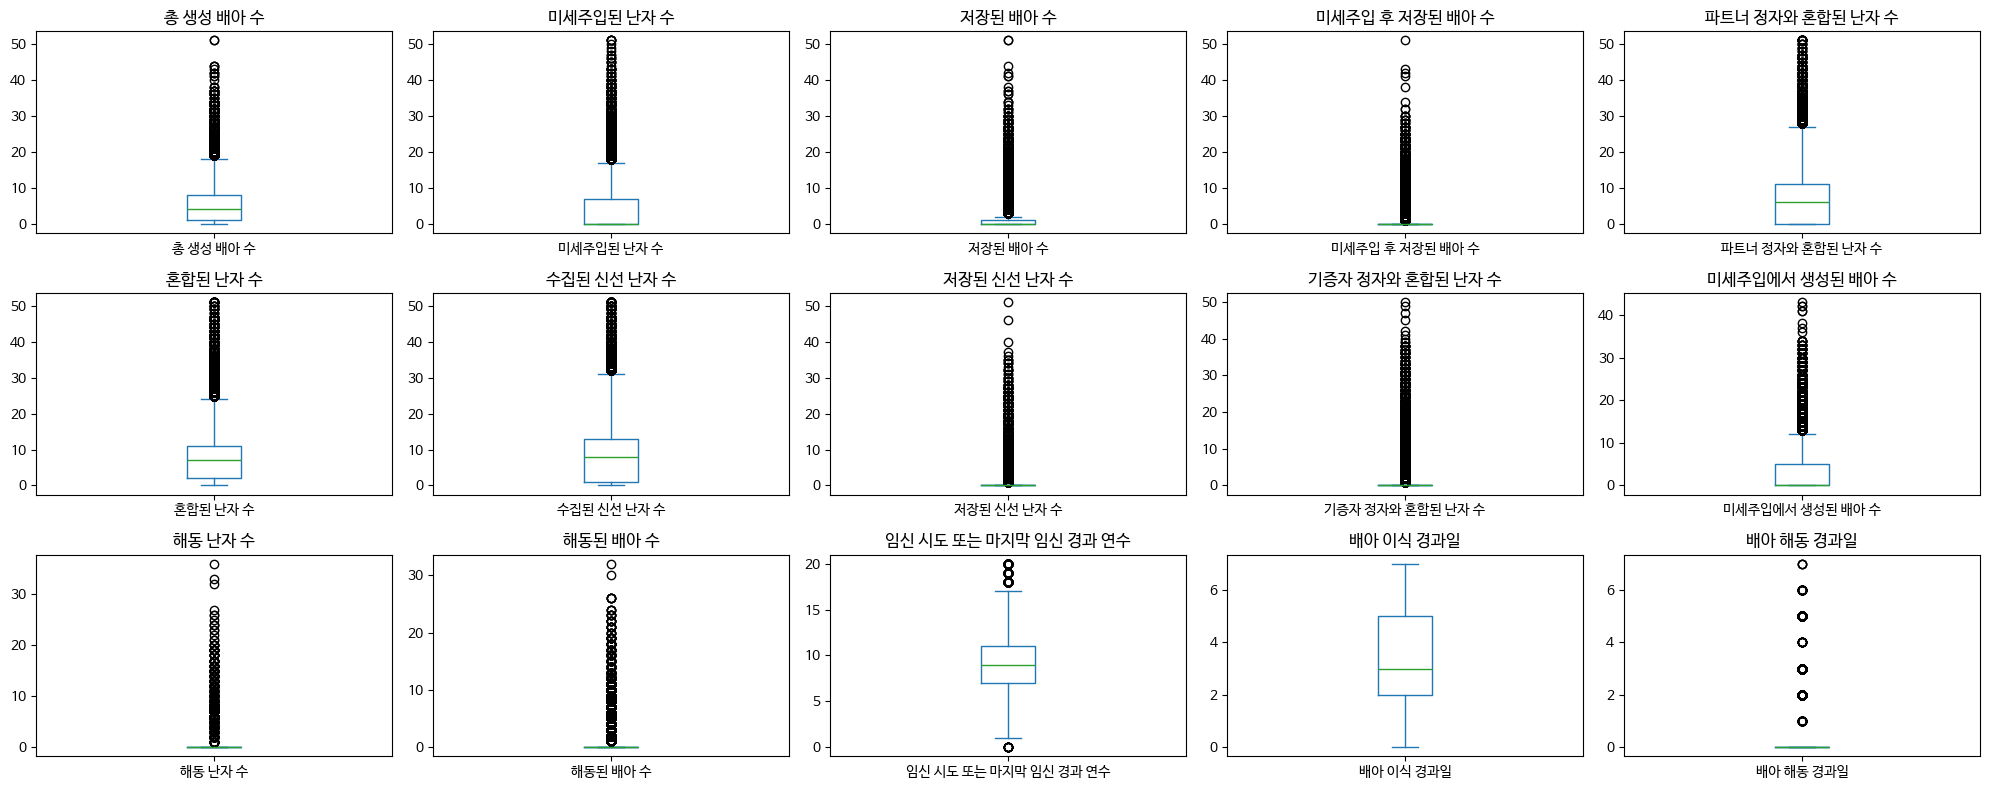

In [35]:
# 캡핑이 아닌, 진짜 튀는 이상치만 시각화로 재확인

# 컬럼별 요약 통계 결과 상위 10개 컬럼
suspect_cols = outlier_summary.head(15)['컬럼'].tolist()

fig, axes = plt.subplots(3, 5, figsize=(4*5, 4*2))
axes = axes.flatten()

for ax, col in zip(axes, suspect_cols):
    train[col].dropna().plot(kind='box', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 💡 **유의미해 보이는 컬럼**

1. **환자 기본 특성**

- **시술 당시 나이**: 가장 강력해 보이는 변수.  
  만18-34세는 성공률 32.3%인데 만43-44세는 11.8%로, 연령대가 올라갈수록 성공률이 단조 감소.
  시술 유형(IVF vs DI): IVF 26.2% vs DI 12.9%로 IVF가 두 배 이상 높다.

2. **시술/치료 이력** — 이전 시도 횟수가 많을수록 오히려 성공률 하락  
  총 시술 횟수, 클리닉 내 총 시술 횟수, IVF 시술 횟수: 0회일 때 성공률이 가장 높고(28~29%), 6회 이상에서는 20% 안팎으로 낮아짐. "누적 실패 경험"을 반영하는 지표로 보임.

3. **배아/난자 관련 수치 지표** — 시술 결과와 직접적으로 연결  
  이식된 배아 수(상관 0.157), 총 생성 배아 수(0.146), 혼합된 난자 수(0.116), 미세주입에서 생성된 배아 수(0.090) 등이 target과 상관이 뚜렷.
단일 배아 이식 여부: 1일 때 36.7% vs 0일 때 22.9%로 차이가 큼.

4. **경과일(시점) 변수**
  배아 이식 경과일: 상관 0.149로 꽤 유의미해보임. 단, 결측률이 17% 존재.

5. **특정 시술 유형(세부 시술)**
  ICSI/BLASTOCYST, IVF/BLASTOCYST 조합이 성공률 35% 내외로 높고, 동결란 재이식 반복(IVF:IVF, ICSI:ICSI)은 1% 수준으로 극단적으로 낮음  
  — 다만 표본 수가 적어 해석에 주의가 필요.

6. **난자/정자 출처**
  난자를 기증받은 경우(31.5%)가 본인 난자(25.8%)보다 오히려 성공률이 높음  
  — 기증 난자가 대개 젊은 공여자에게서 온다는 점과 연결지어 해석할 여지가 있음

<br>

### 💡 중요한 구조적 특징

> **결측치가 무작위가 아니라 시술 유형에 종속되어 있음**

**📈 결측률이 높은 컬럼들**  

| 항목 / 컬럼명 | 결측치 비율 |
| --- | --- |
| 착상 전 유전 검사/진단(PGD, PGS) 여부 | 결측 99% 내외 |
| 임신 시도 경과 연수 | 결측 96% |
| 배아 관련 수치(생성 배아 수, 이식 배아 수 등) 다수 | 결측 약 2.5% |

- 결측 여부 자체가 시술 유형을 알려주는 정보가 될 수 있음.
- 단순 삭제나 평균 대체보다는 "결측 = 해당 없음"으로 인코딩하는 게 맞지 않을지..

### 📝 카테고리별 성공률 확인

In [36]:
# 범주형 컬럼별 성공률 (mean : 그 카테고리에서의 성공률(0~1), count : 표본 수)
target = '임신 성공 여부'
MIN_COUNT = 30  # 최소 표본 수 기준

for c in cat_cols:
    result = train.groupby(c)[target].agg(['mean', 'count']).sort_values('mean', ascending=False)

    # count가 MIN_COUNT 이상인 것만 먼저 필터링
    total = result['count'].sum()
    result = result[result['count'] >= MIN_COUNT]

    # count와 비율을 하나의 문자열로 합치기
    result['count'] = result['count'].apply(lambda x: f'{x:,.0f} ({x/total:.1%})')

    styled = result.style.format({'mean': '{:.1%}'})
    display(styled)



,mean,count
시술 시기 코드,,
TRYBLT,26.9%,"36,713 (14.3%)"
TRJXFG,26.6%,"36,031 (14.1%)"
TRVNRY,26.0%,"36,173 (14.1%)"
TRCMWS,25.7%,"38,090 (14.9%)"
TRXQMD,25.6%,"34,831 (13.6%)"
TRZKPL,25.5%,"35,544 (13.9%)"
TRDQAZ,24.5%,"38,969 (15.2%)"


,mean,count
시술 당시 나이,,
만18-34세,32.3%,"102,476 (40.0%)"
만35-37세,27.8%,"57,780 (22.5%)"
만38-39세,21.7%,"39,247 (15.3%)"
만45-50세,16.8%,"6,918 (2.7%)"
만40-42세,15.9%,"37,348 (14.6%)"
만43-44세,11.8%,"12,253 (4.8%)"
미상,0.0%,329 (0.1%)


,mean,count
시술 유형,,
IVF,26.2%,"250,060 (97.5%)"
DI,12.9%,"6,291 (2.5%)"


,mean,count
배란 자극 여부,,
1,26.6%,"197,720 (77.1%)"
0,23.2%,"58,631 (22.9%)"


,mean,count
배란 유도 유형,,
기록되지 않은 시행,26.8%,"194,432 (75.8%)"
해당없음_또는_미상,22.7%,"61,917 (24.2%)"


...

,mean,count
신선 배아 사용 여부,,
1.000000,26.8%,"210,136 (82.0%)"
0.000000,21.6%,"46,215 (18.0%)"


,mean,count
기증 배아 사용 여부,,
1.000000,32.8%,"2,458 (1.0%)"
0.000000,25.8%,"253,893 (99.0%)"


,mean,count
대리모 여부,,
1.000000,28.9%,"1,049 (0.4%)"
0.000000,25.8%,"255,302 (99.6%)"


,mean,count
PGD 시술 여부,,
1.000000,27.9%,"2,179 (0.9%)"
0.000000,25.8%,"254,172 (99.1%)"


,mean,count
PGS 시술 여부,,
0.000000,25.9%,"254,422 (99.2%)"
1.000000,20.6%,"1,929 (0.8%)"


#### 그룹 1: 환자/시술 기본 정보

- 연령, 시술 유형, 배란자극/유도유형, 난자/정자 출처 등


In [37]:
group1_cols = [
    '시술 당시 나이', '시술 유형', '특정 시술 유형',
    '배란 자극 여부', '배란 유도 유형',
    '난자 출처', '정자 출처',
    '단일 배아 이식 여부'
]
group1_cols = [c for c in group1_cols if c in cat_cols]

for c in group1_cols:
    result = train.groupby(c)[target].agg(['mean', 'count']).sort_values('mean', ascending=False)
    total = result['count'].sum()
    result = result[result['count'] >= MIN_COUNT]
    result['count'] = result['count'].apply(lambda x: f'{x:,.0f} ({x/total:.1%})')
    print()
    styled = result.style.format({'mean': '{:.1%}'})
    display(styled)

,mean,count
시술 당시 나이,,
만18-34세,32.3%,"102,476 (40.0%)"
만35-37세,27.8%,"57,780 (22.5%)"
만38-39세,21.7%,"39,247 (15.3%)"
만45-50세,16.8%,"6,918 (2.7%)"
만40-42세,15.9%,"37,348 (14.6%)"
만43-44세,11.8%,"12,253 (4.8%)"
미상,0.0%,329 (0.1%)


,mean,count
시술 유형,,
IVF,26.2%,"250,060 (97.5%)"
DI,12.9%,"6,291 (2.5%)"


,mean,count
배란 자극 여부,,
1,26.6%,"197,720 (77.1%)"
0,23.2%,"58,631 (22.9%)"


,mean,count
배란 유도 유형,,
기록되지 않은 시행,26.8%,"194,432 (75.8%)"
해당없음_또는_미상,22.7%,"61,917 (24.2%)"


,mean,count
난자 출처,,
기증 제공,31.5%,"15,769 (6.2%)"
본인 제공,25.8%,"234,291 (91.4%)"
미상,12.9%,"6,291 (2.5%)"


,mean,count
정자 출처,,
배우자 제공,26.0%,"229,199 (89.4%)"
기증 제공,24.4%,"27,016 (10.5%)"
미할당,10.7%,122 (0.0%)


,mean,count
단일 배아 이식 여부,,
1.000000,36.7%,"58,383 (22.8%)"
0.000000,22.6%,"197,968 (77.2%)"


1. **시술 당시 나이** — 단조 감소 중 한 구간 예외(만45-50세(16.8%))  
  | 연령대 |  | 임신성공률 | 건수(count) |
  |--|--|--|--|
  | 만18-34세 |	👍🏻 | 32.3% |	102,476 (40.0%) |
  | 만35-37세 |	 | 27.8% |	57,780 (22.5%) |
  | 만38-39세 |	 | 21.7% |	39,247 (15.3%) |
  | 만45-50세 |	💡 | 16.8% |	6,918 (2.7%) |
  | 만40-42세 |	 | 15.9% |	37,348 (14.6%) |
  | 만43-44세 |	 | 11.8% |	12,253 (4.8%) |
  | 미상 |	 | 0.0% |	329 (0.1%) |

  - 표본이 6,918건(2.7%)으로 작은 편이라 우연일 수 있지만, 이 연령대(만45-50세)까지 시술을 지속하는 사람들이 난자 기증 등 특수한 방법을 함께 쓰는 비율이 높아서일 가능성도 있습니다.  
난자 출처와 교차해서 확인해볼 가치가 있습니다.
  - 미상(0.0%, 329건)은 표본이 너무 작아 해석에서 제외합니다.

<br>

2. **배란 유도 유형**  
  |  |  | 임신성공률 | 건수(count) |
  |--|--|--|--|
  | 기록되지 않은 시행 | 👍🏻 | 26.8% | 194,432건 |
  | 해당없음_또는_미상 | - | 22.7% | 61,917건 |  

- 배란 자극 없이 진행한 시술(자연주기 등)이 오히려 성공률이 나쁘지 않다는 걸 시사합니다.  
(기타: '세트로타이드 (억제제)'- 임신 실패, '생식선 자극 호르몬'- 임신 성공)

<br>

3. **난자 출처**
  |  |  | 임신성공률 | 건수(count) |
  |--|--|--|--|
  | 기증 제공 | 👍🏻 | 	31.5% | 15,769 (6.2%) |
  | 본인 제공 | 2 | 	25.8% |	234,291 (91.4%) |
  | 미상 | 3 | 	12.9% |	6,291 (2.5%) |

- 기증 난자가 상대적으로 젊은 공여자에게서 오는 경우가 많아서 성공률이 높은 것으로 보입니다.  
- 파생변수 후보: 난자_기증여부를 강력한 예측 변수로 쓸 수 있습니다.

<br>

4. **정자 출처**
|  |  | 임신성공률 | 건수(count) |
|--|--|--|--|
| 배우자 제공 | 👍🏻 | 26.0% | 229,199 (89.4%)|
| 기증 제공 | 2 | 24.4% | 27,016 (10.5%)|
| 미할당 | - | 10.7% | 122 (0.0%) |
- 표본이 워낙 작아서 우연일 가능성이 있지만, "미할당" 자체가 시술 진행이 원활하지 않았던 특수 케이스일 수 있습니다.

<br>

5. **단일 배아 이식 여부**
|  |  | 임신성공률 | 건수(count) |
|--|--|--|--|
| 단일 이식 | 👍🏻 | 36.7% | 58,383건 |
| 복수 이식 |  -  |22.6% | 197,968건 |

  - 이 변수는 target과의 관련성이 매우 커서 모델에 꼭 남겨야 할 핵심 피처입니다.

<br>

##### **💡 파생변수 아이디어로 연결할 것**
|  |  |
| -- | -- |
| `난자_기증여부` | 이미 4단계에서 만든 `난자_해당없음`과 방향이 반대인 명시적 플래그. 필요시 추가 고려 |
| `연령×난자기증` 상호작용 | 고령이지만 기증 난자를 쓴 경우 성공률이 어떻게 달라지는지 교차 확인해볼 가치 있음 (1번의 만45-50세 예외 현상과 직접 연결됨) |

#### 그룹 2: 불임 원인 컬럼들
- 불임 원인 15개 컬럼 (남성/여성 요인 등) : 불임의 원인이 생산율에 영향을 주는지 확인


In [38]:
group2_cols = [
    '남성 주 불임 원인', '남성 부 불임 원인',
    '여성 주 불임 원인', '여성 부 불임 원인',
    '부부 주 불임 원인', '부부 부 불임 원인',
    '불명확 불임 원인',
    '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애',
    '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증',
    '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태'
]
group2_cols = [c for c in group2_cols if c in cat_cols]
print(f"그룹2 컬럼 수: {len(group2_cols)}개")
print(group2_cols)

for c in group2_cols:
    result = train.groupby(c)[target].agg(['mean', 'count']).sort_values('mean', ascending=False)
    total = result['count'].sum()
    result = result[result['count'] >= MIN_COUNT]
    result['count'] = result['count'].apply(lambda x: f'{x:,.0f} ({x/total:.1%})')
    print(f"=== {c} ===")
    styled = result.style.format({'mean': '{:.1%}'})
    display(styled)

그룹2 컬럼 수: 17개
['남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태']
=== 남성 주 불임 원인 ===


,mean,count
남성 주 불임 원인,,
0,25.9%,"249,041 (97.1%)"
1,22.0%,"7,310 (2.9%)"


=== 남성 부 불임 원인 ===


,mean,count
남성 부 불임 원인,,
0,25.9%,"252,989 (98.7%)"
1,19.8%,"3,362 (1.3%)"


=== 여성 주 불임 원인 ===


...

,mean,count
불임 원인 - 정자 면역학적 요인,,
0,25.8%,"256,350 (100.0%)"


=== 불임 원인 - 정자 운동성 ===


,mean,count
불임 원인 - 정자 운동성,,
0,25.8%,"256,254 (100.0%)"
1,17.5%,97 (0.0%)


=== 불임 원인 - 정자 형태 ===


,mean,count
불임 원인 - 정자 형태,,
0,25.8%,"256,208 (99.9%)"
1,22.4%,143 (0.1%)


##### **1. 성공률에 실제로 영향을 주는 것으로 보이는 컬럼**

① 주/부 원인 계열 (6개) — 불임 원인이 "있다(1)"고 명시되면 성공률이 낮음
  | 컬럼 | 원인 없음(0) | 원인 있음(1) | 차이	|
  |--|--|--|--|
  | 남성 주 불임 원인 | 25.9%	| 22.0%	| -3.9%p |
  | 남성 부 불임 원인	| 25.9%	| 19.8%	| **-6.1%p** |
  | 여성 주 불임 원인	| 26.0%	| 21.9%	| -4.1%p |
  | 여성 부 불임 원인	| 25.9%	| 19.6%	| **-6.3%p** |
  | 부부 주 불임 원인	| 26.0%	| 22.0%	| -4.0%p |
  | 부부 부 불임 원인	| 25.9%	| 18.7%	| **-7.2%p** |

- 일관되게 "명확한 불임 원인이 없는 경우"가  3~7%p 높습니다.  
표본도 다 수천 건 이상이라 신뢰할 만한 패턴으로 보입니다.  
- "부(secondary) 원인"의 성공률 하락 폭이 더 크다는 점도 눈에 띄입니다. (예: 남성 부 -6.1%p vs 남성 주 -3.9%p).

<br>

② 특이하게 "원인이 있는 게 오히려 유리"한 2개
  | 컬럼 | 원인 없음(0) | 원인 있음(1) | 차이	|
  |--|--|--|--|
  | 불임 원인 - 남성 요인 |	24.6% |	28.0% |	+3.4%p |
  | 불임 원인 - 배란 장애 |	25.4% |	28.7% |	+3.3%p |

- 이 둘은 반대 방향입니다. 원인이 명확히 "이거다"라고 특정될수록 오히려 치료 타겟이 명확해져서 성공률이 높아지는 것으로 해석해볼 수 있겠습니다.  
예를 들어 배란 장애는 배란 유도제로 비교적 잘 대응되는 원인이라 그럴 수 있습니다. 표본도 각각 95,466건(37.2%), 33,426건(13.0%)으로 충분히 큽니다.

##### **2. 사실상 무의미** (표본 극소수 또는 차이 없음)
- `불명확 불임 원인`, `불임 원인 - 난관 질환`, `불임 원인 - 자궁내막증`: 0/1 간 차이가 0.4%p 이내로 사실상 없음
- `불임 원인 - 여성 요인`, `불임 원인 - 자궁경부 문제`, `불임 원인 - 정자 면역학적 요인`: 값이 전부 0 (100.0%) → 이 컬럼들은 train 데이터에 사실상 아무 정보가 없습니다 (분산이 0)
- `불임 원인 - 정자 농도`(276건), `정자 운동성`(97건), `정자 형태`(143건): 1값이 극소수라 통계적으로 의미 부여하기 어려움

#### **파생변수/피처 정리 방향**
1. 제거 - 분산이 0인 컬럼
- 여성 요인, 자궁경부 문제, 정자 면역학적 요인은 모델에 넣어도 아무 기여를 못할 가능성이 큼
2. **불임 원인 개수 파생변수**를 만들 때는 이 17개를 다 동일 가중치로 더하기보다, 1번(주/부 원인, 방향성 뚜렷)만 따로 모아서 "명확히 지목된 원인 개수"로 만들기
3. "남성 요인"과 "배란 장애"는 방향이 반대라, 단순 합산(개수 세기)에 넣으면 신호가 서로 상쇄될 위험이 있습니다. 이 둘은 별도 플래그로 분리해서 넣는 게 안전

#### 그룹 3: 배아/시술 세부 플래그
- 단일 배아 이식 여부, 착상 전 유전검사 사용 여부 등
- 배아/난자 관련 이진(0/1) 컴럼들

In [39]:
group3_cols = [
    '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부',
    'PGD 시술 여부', 'PGS 시술 여부',
    '배아 생성 주요 이유', '총 시술 횟수',
    '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부',
    '대리모 여부'
]
group3_cols = [c for c in group3_cols if c in cat_cols]
print(f"그룹3 컬럼 수: {len(group3_cols)}개")
print(group3_cols)

for c in group3_cols:
    result = train.groupby(c)[target].agg(['mean', 'count']).sort_values('mean', ascending=False)
    total = result['count'].sum()
    result = result[result['count'] >= MIN_COUNT]
    result['count'] = result['count'].apply(lambda x: f'{x:,.0f} ({x/total:.1%})')
    styled = result.style.format({'mean': '{:.1%}'})
    display(styled)

그룹3 컬럼 수: 11개
['단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', 'PGD 시술 여부', 'PGS 시술 여부', '배아 생성 주요 이유', '총 시술 횟수', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부']


,mean,count
단일 배아 이식 여부,,
1.000000,36.7%,"58,383 (22.8%)"
0.000000,22.6%,"197,968 (77.2%)"


,mean,count
착상 전 유전 검사 사용 여부,,
0.000000,26.0%,"253,633 (98.9%)"
1.000000,14.8%,"2,718 (1.1%)"


,mean,count
착상 전 유전 진단 사용 여부,,
0.000000,25.9%,"253,155 (98.8%)"
1.000000,19.2%,"3,196 (1.2%)"


,mean,count
PGD 시술 여부,,
1.000000,27.9%,"2,179 (0.9%)"
0.000000,25.8%,"254,172 (99.1%)"


...

,mean,count
총 시술 횟수,,
0회,29.1%,"97,599 (38.1%)"
1회,25.0%,"56,819 (22.2%)"
2회,24.4%,"39,338 (15.3%)"
3회,23.6%,"24,531 (9.6%)"
4회,22.8%,"15,141 (5.9%)"
5회,21.6%,"9,106 (3.6%)"
6회 이상,20.3%,"13,817 (5.4%)"


,mean,count
동결 배아 사용 여부,,
0.000000,26.4%,"216,225 (84.3%)"
1.000000,22.9%,"40,126 (15.7%)"


,mean,count
신선 배아 사용 여부,,
1.000000,26.8%,"210,136 (82.0%)"
0.000000,21.6%,"46,215 (18.0%)"


,mean,count
기증 배아 사용 여부,,
1.000000,32.8%,"2,458 (1.0%)"
0.000000,25.8%,"253,893 (99.0%)"


,mean,count
대리모 여부,,
1.000000,28.9%,"1,049 (0.4%)"
0.000000,25.8%,"255,302 (99.6%)"


1. **PGD/PGS/착상 전 유전검사**
  | 컬럼 | 안 받음 |	받음 | 차이 |
  |---|--|--|--|
  | 착상 전 **유전 검사** 사용 여부 | 26.0% |	14.8% |	-11.2%p |
  | 착상 전 **유전 진단** 사용 여부 |	25.9% |	19.2% |	-6.7%p |
  | PGS 시술 여부 |	25.9% |	20.6% |	-5.3%p |
  | PGD 시술 여부 |	25.8% |	27.9% |	+2.1%p (예외) |

-  **유전검사**를 받는 경우 대체로 성공률이 낮습니다. 검사를 받을 정도면 이미 반복 실패나 고령 등 위험 요인이 겹쳐있는 경우가 많다는 해석이 맞아떨어집니다.
- PGS(염색체 이수성 검사)는 주로 반복착상실패/고령 환자에게 쓰이니 방향이 반대로 나온 게 임상적으로 자연스럽습니다.
- PGD(착상 전 유전 진단)는 반대로 받을 경우 성공률이 더 높습니다.(+2.1%p)  
특정 유전질환 보인자 부부가 배아를 선별하는 목적이 강해서, 오히려 "건강한 배아만 골라 이식"하는 효과로 성공률이 소폭 높아진 것으로 해석할 수 있습니다.  

<br>

2. **배아 생성 주요 이유** — 가장 극적인

- "현재 시술용"이 아닌 목적(저장용, 기증용, 난자저장용 등)은 성공률이 거의 0%에 가깝습니다.

| 카테고리 | 성공률 |
|--|--|
| 기증용, 현재 시술용 | 38.0% |
| 현재 시술용 | 27.4% |
| 해당없음(DI) | 12.9% |
| **배아 저장용** | **0.1%** |
| 기증용, 배아 저장용 | 0.0% |
| 기증용 | 0.0% |
| 기증용, 난자 저장용 | 0.0% |
| 난자 저장용 | 0.0% |

— "배아 저장용", "난자 저장용", "기증용"으로 만든 배아/난자는 이번 시술 주기에 이식할 목적이 아니므로, 애초에 임신 성공 여부를 평가할 대상이 아닙니다.  
즉 target(임신 성공 여부)이라는 게 "이번 주기에 이식해서 임신했는지"를 뜻하니, "저장만 하고 이식 안 한 사람"은 구조적으로 실패(0)로 기록되기 때문입니다..
- 💡 이 카테고리들(현재 시술용이 아닌 것)을 걸러내지 않고 모델에 그대로 넣으면,  
모델이 **"배아 저장을 했다 = 임신 실패"**라는 잘못된 인과관계를 학습할 위험이 큽니다.

In [40]:
# 배아 생성 이유 중 "현재 시술용"이 포함 안 된 케이스는 별도 플래그로 표시 - IVF인데 당장 이식 목적 아님
def make_non_transfer_flag(df):
    df = df.copy()
    col = df['배아 생성 주요 이유']

    # "현재 시술용"이 아니면서, DI(해당없음)도 아닌 경우만 1
    is_di = (col == '해당없음')
    is_current_use = col.str.contains('현재 시술용', na=False)

    df['배아_비시술목적_IVF'] = ((~is_current_use) & (~is_di)).astype(int)
    return df

train = make_non_transfer_flag(train)
test = make_non_transfer_flag(test)

print(train['배아_비시술목적_IVF'].value_counts())



배아_비시술목적_IVF
0    243916
1     12435
Name: count, dtype: int64


In [41]:
# 배아 생성 주요 이유의 희귀 카테고리 정리 + 비시술목적 플래그 최종 정리
def finalize_embryo_reason(df):
    df = df.copy()
    col = df['배아 생성 주요 이유'].fillna('해당없음')

    is_di = (col == '해당없음')
    is_current_use = col.str.contains('현재 시술용', na=False)
    df['배아_비시술목적_IVF'] = ((~is_current_use) & (~is_di)).astype(int)

    return df

train = finalize_embryo_reason(train)
test = finalize_embryo_reason(test)

3. 총 시술 횟수
0회(29.1%)부터 6회 이상(20.3%)까지 시술시 누적될수록 감소합니다.

<br>

4. 동결 vs 신선 배아 — 신선 배아가 유리  
- 신선 배아 사용(26.8%)이 동결 배아 사용(22.9%)보다 성공률이 높습니다.  
이건 임상적으로도 알려진 패턴과 일치합니다 (동결-해동 과정에서 배아 손실 가능성).

<br>

5. 기증 배아 / 대리모 — 표본은 작지만 오히려 성공률 높음  
|  | 사용 안함[0] | 사용[1] | 사용 건수 |
| 기증 배아 | 25.8% | 32.8% | 2,458건(1.0%) |
| 대리모 | 25.8% | 28.9% | 1,049건(0.4%) |

- 둘 다 표본이 작긴 하지만 방향이 일관되게 "특수 케이스가 오히려 유리"하다는 걸 보여줍니다.



## 🛠️ 피처 엔지니어링

### 1. 순서형 변수 인코딩
- 문자열로 된 순서형 범주(연령대, 횟수구간 등)를 숫자로 변환

In [42]:
import re

# ① "N회" 계열 컬럼 일괄 처리
count_cols = ['총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수',
              '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
              '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수']

def parse_count(val):
    if pd.isnull(val):
        return np.nan
    if val == '6회 이상':
        return 6
    return int(re.sub('회', '', val))

def apply_ordinal_counts(df):
    df = df.copy()
    for col in count_cols:
        df[f'{col}_ord'] = df[col].apply(parse_count)
        df[f'{col}_상한도달'] = (df[col] == '6회 이상').astype(int)
    return df

train = apply_ordinal_counts(train)
test = apply_ordinal_counts(test)

# 확인
print(train[['총 시술 횟수', '총 시술 횟수_ord', '총 시술 횟수_상한도달']].drop_duplicates().sort_values('총 시술 횟수_ord'))

   총 시술 횟수  총 시술 횟수_ord  총 시술 횟수_상한도달
0       0회            0             0
2       1회            1             0
10      2회            2             0
12      3회            3             0
16      4회            4             0
25      5회            5             0
11   6회 이상            6             1


In [43]:
# ② 시술 당시 나이 → 순서형 매핑
age_map = {
    '만18-34세': 1, '만35-37세': 2, '만38-39세': 3,
    '만40-42세': 4, '만43-44세': 5, '만45-50세': 6,
    '미상': np.nan, '알 수 없음': np.nan,
}

def apply_age_ordinal(df):
    df = df.copy()
    df['시술 당시 나이_ord'] = df['시술 당시 나이'].map(age_map)
    return df

train = apply_age_ordinal(train)
test = apply_age_ordinal(test)

# 확인
print(train[['시술 당시 나이', '시술 당시 나이_ord']].drop_duplicates().sort_values('시술 당시 나이_ord'))
print()
print('매핑 안 된 값(NaN인데 원본이 미상/알수없음이 아닌 경우):')
check = train[train['시술 당시 나이_ord'].isnull() & ~train['시술 당시 나이'].isin(['미상', '알 수 없음'])]
print(check['시술 당시 나이'].unique())

    시술 당시 나이  시술 당시 나이_ord
0    만18-34세           1.0
3    만35-37세           2.0
5    만38-39세           3.0
7    만40-42세           4.0
15   만43-44세           5.0
1    만45-50세           6.0
552       미상           NaN

매핑 안 된 값(NaN인데 원본이 미상/알수없음이 아닌 경우):
[]



① `N회` 계열 (10개 컬럼):  
- '0회', '1회', '2회'... 형식이라 규칙이 하나로 통일
- '6회 이상'처럼 텍스트가 섞인 것 주의

② `시술 당시 나이` (1개 컬럼):
- 연령 구간 문자열이라 별도 매핑이 필요
- 결측치 처리한 '미상' -> NaN 처리


- 새로 만든 _ord 컬럼 최종 목록
  - 시술 당시 나이 - `시술 당시 나이_ord`
  - 시술 횟수 계열 10개에 대한 _상한도달 플래그 (6회 이상)  
  `총 시술 횟수_ord`, `클리닉 내 총 시술 횟수_ord`, `IVF 시술 횟수_ord`, `DI 시술 횟수_ord`, `총 임신 횟수_ord`, `IVF 임신 횟수_ord`, `DI 임신 횟수_ord`, `총 출산 횟수_ord`, `IVF 출산 횟수_ord`, `DI 출산 횟수_ord`

### 2. 비율 파생변수
- 이전 상관관계 분석에서 target과 연관이 높았던 수치들을 조합

| 비율 지표 | 계산식 | 의미 |
|--|--|--|
| | | |
| 수정률 | 혼합된 난자 수 / 수집된 신선 난자 수 | 채취한 난자 중 실제로 수정 시도한 비율
| 배아생성률 | 총 생성 배아 수 / 혼합된 난자 수 | 수정 시도한 난자 중 배아로 발달한 비율
| 배아저장률 | 저장된 배아 수 / 총 생성 배아 수 | 만든 배아 중 이식 안 하고 저장한 비율
| 착상시도율(이식률) | 이식된 배아 수 / 총 생성 배아 수 | 만든 배아 중 실제 이식까지 간 비율
| 미세주입활용률 | 미세주입된 난자 수 / 수집된 신선 난자 수 | 채취 난자 중 ICSI를 적용한 비율

- 0으로 나누는 문제 처리 방법

분모가 0인 경우(예: 애초에 난자를 하나도 못 채취한 사람) 0/0은 계산 불가능(NaN)이 되고, 양수/0은 무한대(inf)가 됩니다. 둘 다 모델에 그대로 넣으면 안 되니, np.where로 분모가 0이면 결과를 0 또는 NaN으로 명시적으로 처리합니다.

In [44]:
def safe_ratio(numerator, denominator):
    return np.where(denominator > 0, numerator / denominator, np.nan)

def apply_ratio_features(df):
    df = df.copy()
    df['수정률'] = safe_ratio(df['혼합된 난자 수'], df['수집된 신선 난자 수'])
    df['배아생성률'] = safe_ratio(df['총 생성 배아 수'], df['혼합된 난자 수'])
    df['이식률'] = safe_ratio(df['이식된 배아 수'], df['총 생성 배아 수'])
    df['배아저장률'] = safe_ratio(df['저장된 배아 수'], df['총 생성 배아 수'])
    df['미세주입활용률'] = safe_ratio(df['미세주입된 난자 수'], df['수집된 신선 난자 수'])
    return df

train = apply_ratio_features(train)
test = apply_ratio_features(test)

In [45]:
ratio_cols = ['수정률', '배아생성률', '이식률', '배아저장률', '미세주입활용률']

def clip_ratio_features(df):
    df = df.copy()
    for col in ratio_cols:
        df[f'{col}_비정상초과'] = (df[col] > 1).astype(int)
        df[col] = df[col].clip(upper=1.0)
    return df

train = clip_ratio_features(train)
test = clip_ratio_features(test)

# 최종 확인
print(train[ratio_cols].describe())

                 수정률          배아생성률            이식률          배아저장률  \
count  196215.000000  203410.000000  196711.000000  196711.000000   
mean        0.862310       0.662104       0.366442       0.179834   
std         0.211736       0.250117       0.315422       0.269227   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.785714       0.500000       0.125000       0.000000   
50%         1.000000       0.692308       0.250000       0.000000   
75%         1.000000       0.846154       0.500000       0.333333   
max         1.000000       1.000000       1.000000       1.000000   

             미세주입활용률  
count  196215.000000  
mean        0.469901  
std         0.418153  
min         0.000000  
25%         0.000000  
50%         0.583333  
75%         0.875000  
max         1.000000  


In [46]:
for col in ratio_cols:
    over_1 = (train[col] > 1).sum()
    print(f'{col}: 1.0 초과 건수 = {over_1}건 (전체의 {over_1/len(train)*100:.2f}%)')

수정률: 1.0 초과 건수 = 0건 (전체의 0.00%)
배아생성률: 1.0 초과 건수 = 0건 (전체의 0.00%)
이식률: 1.0 초과 건수 = 0건 (전체의 0.00%)
배아저장률: 1.0 초과 건수 = 0건 (전체의 0.00%)
미세주입활용률: 1.0 초과 건수 = 0건 (전체의 0.00%)


In [47]:
over_cols_check = train[train['이식률'] > 1][
    ['특정 시술 유형', '동결 배아 사용 여부', '신선 배아 사용 여부',
     '총 생성 배아 수', '이식된 배아 수', '이식률']
]
print(over_cols_check.head(15))
print()
print('동결 배아 사용 여부 분포 (1.0 초과 건 중):')
print(train.loc[train['이식률'] > 1, '동결 배아 사용 여부'].value_counts())

Empty DataFrame
Columns: [특정 시술 유형, 동결 배아 사용 여부, 신선 배아 사용 여부, 총 생성 배아 수, 이식된 배아 수, 이식률]
Index: []

동결 배아 사용 여부 분포 (1.0 초과 건 중):
Series([], Name: count, dtype: int64)


### 3. 조합형 파생변수
- 여러 컬럼을 조합해서 하나의 요약 지표로 만들기

1. 복합 시술 여부 플래그 (이미 시술포함_ICSI 등 생성함)

2. 불임 원인 컬럼 15개를 합쳐 '불임원인개수' 지표 생성

In [48]:

def apply_remaining_derived_features(df):
    df = df.copy()

    # ── 1. 고위험연령군 플래그 (40세 이상) ──
    df['고위험연령군'] = (df['시술 당시 나이_ord'] >= 4).astype(int)

    # ── 2. 과거 실패/손실 이력 ──
    df['past_failed_cycles'] = df['총 시술 횟수_ord'] - df['총 임신 횟수_ord']
    df['past_pregnancy_loss'] = df['총 임신 횟수_ord'] - df['총 출산 횟수_ord']

    # ── 3. 연령 × 시술횟수 상호작용 ──
    df['age_cycle_interaction'] = df['시술 당시 나이_ord'] * df['총 시술 횟수_ord']

    # ── 4. 불임원인 개수 (방향이 다른 것들 분리) ──
    # 4-1) "원인 있음 = 성공률 낮음" 그룹 (주/부 원인 6개)
    negative_cause_cols = ['남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인',
                            '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인']
    df['명확원인_개수'] = df[negative_cause_cols].sum(axis=1)

    # 4-2) "원인 있음 = 성공률 높음" 그룹은 방향이 반대라 개별 유지 (원본 컬럼 그대로 사용)
    #      불임 원인 - 남성 요인, 불임 원인 - 배란 장애 → 이미 원본 컬럼에 있음

    # ── 5. 미사용 배아수 (동결 재사용 케이스 음수 방지) ──
    df['미사용_배아수'] = (df['총 생성 배아 수'] - df['이식된 배아 수'] - df['저장된 배아 수']).clip(lower=0)

    # ── 6. 배아 생성 주요 이유: 비시술목적 플래그 ──
    col = df['배아 생성 주요 이유'].fillna('해당없음')
    is_di = (col == '해당없음')
    is_current_use = col.str.contains('현재 시술용', na=False)
    df['배아_비시술목적_IVF'] = ((~is_current_use) & (~is_di)).astype(int)

    return df

train = apply_remaining_derived_features(train)
test = apply_remaining_derived_features(test)

In [49]:
# 희귀 카테고리 정리 (배란 유도 유형, 배아 생성 주요 이유)

def group_rare_categories(df, col, rare_list):
    df = df.copy()
    df[col] = df[col].apply(lambda x: '기타' if x in rare_list else x)
    return df

for col in ['배란 유도 유형', '배아 생성 주요 이유']:
    value_counts = train[col].value_counts()
    rare_categories = value_counts[value_counts < 30].index.tolist()
    print(f'{col} 희귀 카테고리:', rare_categories)
    train = group_rare_categories(train, col, rare_categories)
    test = group_rare_categories(test, col, rare_categories)

배란 유도 유형 희귀 카테고리: ['세트로타이드 (억제제)', '생식선 자극 호르몬']
배아 생성 주요 이유 희귀 카테고리: ['기증용, 배아 저장용, 현재 시술용', '난자 저장용, 배아 저장용', '난자 저장용, 현재 시술용', '연구용, 현재 시술용', '난자 저장용, 배아 저장용, 연구용']


In [50]:
# 파생변수 최종 확인

new_cols = ['고위험연령군', 'past_failed_cycles', 'past_pregnancy_loss', 'age_cycle_interaction',
            '명확원인_개수', '미사용_배아수', '배아_비시술목적_IVF']

print(train[new_cols].describe())
print()
print('train shape:', train.shape, '/ test shape:', test.shape)
print()
print('결측 남은 컬럼:')
print(train.isna().mean()[train.isna().mean() > 0].sort_values(ascending=False))

              고위험연령군  past_failed_cycles  past_pregnancy_loss  \
count  256351.000000       256351.000000        256351.000000   
mean        0.220475            1.322776             0.072401   
std         0.414568            1.579573             0.279877   
min         0.000000            0.000000             0.000000   
25%         0.000000            0.000000             0.000000   
50%         0.000000            1.000000             0.000000   
75%         0.000000            2.000000             0.000000   
max         1.000000            6.000000             4.000000   

       age_cycle_interaction        명확원인_개수        미사용_배아수   배아_비시술목적_IVF  
count          256022.000000  256351.000000  256351.000000  256351.000000  
mean                4.091703       0.126619       2.680040       0.048508  
std                 6.066280       0.599379       3.325173       0.214837  
min                 0.000000       0.000000       0.000000       0.000000  
25%                 0.000000      

- `past_failed_cycles`: "총 시술 횟수 - 총 임신 횟수", 시도했지만 임신에 실패한 횟수를 근사합니다. (완전히 정확하진 않지만, 순서형 인코딩된 값으로 만들 수 있는 최선의 근사치입니다.)

- `명확원인_개수`: 그룹 2에서 확인했듯 "원인 있음 → 성공률 낮음" 방향이 일관된 6개 컬럼만 모아서 합산했습니다. 방향이 반대인 `불임 원인 - 남성 요인`, `불임 원인 - 배란 장애`는 섞으면 신호가 상쇄되니 원본 그대로 남겼습니다.

- `미사용_배아수`: `clip(lower=0)`으로 음수(동결배아 재사용 등으로 이식수가 생성수보다 큰 경우)를 0으로 막았습니다.

- `배아_비시술목적_IVF`: 방금 확인한 대로, DI(해당없음)는 제외하고 IVF인데 이식 목적이 아니었던 케이스만 표시합니다.

In [51]:
# train, test의 컬럼 수 차이 확인 (142개 vs 136개)

train_cols = set(train.columns) - {'임신 성공 여부'}
test_cols = set(test.columns)

print('train에만 있는 컬럼:', train_cols - test_cols)
print('test에만 있는 컬럼:', test_cols - train_cols)

train에만 있는 컬럼: set()
test에만 있는 컬럼: set()


##### 결측 남은 컬럼 (✅ 정상)
- 난자 해동 경과일, 임신 시도 경과 연수, 배아 해동 경과일, 난자 채취/혼합 경과일, 배아 이식 경과일 → 그룹 B, 의도적으로 NaN 유지
- 수정률, 미세주입활용률, 이식률, 배아저장률, 배아생성률 → 분모가 0(DI 시술 등)이라 NaN 처리된 것 (safe_ratio 함수가 의도한 대로 작동)
- 시술 당시 나이_ord, age_cycle_interaction (0.13%) → 미상으로 채워진 329건이 매핑에서 NaN이 된 것 (이 컬럼은 애초에 age_map에서 '미상': np.nan으로 설계했었죠)
- 특정 시술 유형 (0.0008%, 2건) → 무시 가능한 수준

#### **✅ 완료된 것**
✔️ 결측치 처리 (Sentinel 통일 + 그룹 A/B/C 분류 처리)  
✔️ 이상치 처리 (51.0 상한 캡핑 플래그)  
✔️ 순서형 인코딩 (연령대, 시술/임신/출산 횟수)  
✔️ 비율 파생변수 (수정률, 이식률 등 + 1.0 초과 클리핑)  
✔️ 조합형 파생변수 (고위험연령군, 과거실패/손실횟수, 상호작용변수, 불임원인개수, 미사용배아수, 배아 비시술목적 플래그)  
✔️ 희귀 카테고리 정리  
✔️ train/test 컬럼 정합성 확인 완료  

# <font color="darkgreen">[3단계] 모델링</font>

## 🧠 **베이스라인 모델링**

- Stratified K-Fold로 기본 XGBoost 학습
- 베이스라인 성능(AUC 등) 확인


### 1️⃣ 피처/타겟 분리 및 최소 정리

- `ord_source_cols` 제외: `시술 당시 나이`, `총 시술 횟수` 같은 원본 문자열은 이미 _ord로 숫자화해뒀기 때문에 중복을 피하기 위해 제외.
- 나머지 문자열 컬럼(예: `시술 유형`, `난자 출처`, `배아 생성 주요 이유`)은 아직 인코딩 안 했으니 category 타입으로 바꿔서 XGBoost가 직접 처리.

In [52]:
# 1단계
target = '임신 성공 여부'

# ID, target 제외
drop_cols = ['ID', target]

# 순서형으로 이미 인코딩된 원본 문자열 컬럼은 중복이라 제외 (베이스라인이니 최소한만 정리)
ord_source_cols = ['시술 당시 나이'] + count_cols  # count_cols는 앞서 정의한 10개 횟수 컬럼

X_train_full = train.drop(columns=drop_cols + ord_source_cols)
y_train = train[target]

X_test_full = test.drop(columns=[c for c in drop_cols if c in test.columns] + ord_source_cols)

print(X_train_full.shape, X_test_full.shape)

(256351, 124) (90067, 124)


### 2️⃣ 남은 문자열(범주형) 컬럼을 category 타입으로 변환

- `union_categoricals`: train과 test에서 카테고리 값이 다르면(예: train에만 있는 희귀값) 에러가 날 수 있어서, 두 데이터의 카테고리를 통일해주어야한다.

In [53]:
# 2단계

obj_cols = X_train_full.select_dtypes(include='object').columns.tolist()
print('범주형(문자열)로 남은 컬럼:', obj_cols)

for col in obj_cols:
    X_train_full[col] = X_train_full[col].astype('category')
    X_test_full[col] = X_test_full[col].astype('category')

# train/test 카테고리 목록을 통일 (test에만 있는 값이 있으면 에러 방지)
for col in obj_cols:
    all_categories = pd.api.types.union_categoricals(
        [X_train_full[col], X_test_full[col]]
    ).categories
    X_train_full[col] = X_train_full[col].cat.set_categories(all_categories)
    X_test_full[col] = X_test_full[col].cat.set_categories(all_categories)

범주형(문자열)로 남은 컬럼: ['시술 시기 코드', '시술 유형', '특정 시술 유형', '배란 유도 유형', '배아 생성 주요 이유', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이']


### 3️⃣ Stratified K-Fold + XGBoost 학습
- `enable_categorical=True` : XGBoost가 문자열을 원-핫 인코딩 없이 바로 처리 가능(버전 1.6 이상)

- `early_stopping_rounds=50`: validation 성능이 50라운드 동안 개선 안 되면 멈춰서 과적합을 방지합니다.

- `oof_preds`: Out-of-fold 예측값으로, 5개 fold 전체에 대한 검증 성능을 종합적으로 확인할 수 있습니다.

In [54]:
# 3단계
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X_train_full))
test_preds = np.zeros(len(X_test_full))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y_train)):
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        enable_categorical=True,
        tree_method='hist',
        early_stopping_rounds=50,
        random_state=42
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}')

    test_preds += model.predict_proba(X_test_full)[:, 1] / N_SPLITS

print()
print(f'평균 AUC: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})')
print(f'전체 OOF AUC: {roc_auc_score(y_train, oof_preds):.5f}')


Fold 1 AUC: 0.73797
Fold 2 AUC: 0.74268
Fold 3 AUC: 0.74008
Fold 4 AUC: 0.73808
Fold 5 AUC: 0.74084

평균 AUC: 0.73993 (+/- 0.00177)
전체 OOF AUC: 0.73992


- **평균 AUC: 0.7399** — 헬스케어/의료 예측 문제치고 견고한 시작점

- **편차 0.00177** — fold별로 0.738~0.743 사이에 촘촘하게 모여있어서 매우 안정적
  - Stratified K-Fold가 잘 작동해서 fold 간 데이터 분포가 고르게 나뉘었다는 뜻
  - 모델이 특정 fold에만 과적합되거나 튀는 현상 없이 일관되게 학습되고 있다는 뜻
- **평균 AUC(0.73993)와 전체 OOF AUC(0.73992)가 거의 동일**
  두 값이 크게 다르면 fold 간 불균형이나 계산상 문제를 의심해야 하는데, 지금은 사실상 같은 값이라 신뢰할 수 있는 베이스라인

## **Feature Selection (검증)**

- 원본 문자열 컬럼 vs 인코딩된 컬럼 중복 정리
- 모델에 넣을 최종 피처 리스트 확정

### 1️⃣ 피처 중요도 확인



In [63]:
importance_list = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y_train)):
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, eval_metric='auc',
        enable_categorical=True, tree_method='hist',
        early_stopping_rounds=50, random_state=42
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    importance_list.append(model.feature_importances_)

# 5개 fold 평균 importance
avg_importance = np.mean(importance_list, axis=0)
importance_df = pd.DataFrame({
    'feature': X_train_full.columns,
    'importance': avg_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(25).to_string())

KeyboardInterrupt: 

In [61]:

pd.set_option('display.max_rows', 200)
print(importance_df.to_string())

NameError: name 'importance_df' is not defined

##### **1위: 이식된 배아 수 (17.5%)**

혼자 전체 중요도의 17.5%를 차지합니다. 이전 EDA 상관관계 분석에서도 가장 상관이 높았던 변수(0.157)였는데, 실제 모델에서도 그대로 확인됐습니다. 배아를 몇 개 이식했는지가 성공 여부에 가장 결정적이라는 게 데이터와 모델 양쪽에서 일관되게 나온 셈입니다.

##### **2위: 시술 유형 (10.6%)** — IVF/DI 구분이 여전히 강력

##### **❌ Importance = 0**인 피처 (완전히 안 쓰인 것) — 24개

1. 상한도달 플래그들 (거의 다 0)
저장된 신선 난자 수_상한도달, 파트너 정자와 혼합된 난자 수_상한도달, 혼합된 난자 수_상한도달, 총 생성 배아 수_상한도달, 미세주입된 난자 수_상한도달, 저장된 배아 수_상한도달, 미세주입 후 저장된 배아 수_상한도달, 수집된 신선 난자 수_상한도달, 그리고 시술/임신/출산 횟수의 _상한도달 전부(IVF임신횟수, DI출산횟수, IVF출산횟수, DI임신횟수, 총출산횟수, 총임신횟수)  
  **→ 51.0 캡핑 플래그와 '6회 이상' 플래그가 전부 무용지물**  
  원본 수치값(예: 저장된 배아 수)이 이미 51이라는 값 자체로 캡핑 정보를 담고 있어서, 트리 모델이 "51 이상이면 오른쪽 가지로"라는 분기를 원본 값만으로 충분히 학습할 수 있었던 것. 플래그가 원본과 완전히 중복된 정보였던 것.

2. 분산이 0이었던 컬럼들  
불임 원인 - 정자 면역학적 요인, 불임 원인 - 자궁경부 문제, 불임 원인 - 여성 요인  
→ "값이 전부 0(100%)"이라 예상했던 그대로.

3. 비율 클리핑 플래그들도 대부분 0
수정률_비정상초과, 배아생성률_비정상초과, 미세주입활용률_비정상초과  
→ 이식률_비정상초과(0.0006, 극히 미미)만 살짝 쓰이고 나머지는 전혀 안 쓰였습니다.

4. 시술포함 플래그 일부
시술포함_GIFT, 시술포함_IVI, 시술포함_FER  
→ 이것도 0. GIFT, FER 자체가 워낙 희귀 케이스라 모델이 분기 기준으로 못 쓴 것으로 보입니다.

##### **파생변수들의 성적**

- 아주 좋은 성적을 낸 것들:

  - 배아 이식 경과일_결측여부(8.0%, 3위): 그룹 B에서 만든 결측 플래그가 원본 값보다도 훨씬 중요하게 쓰였습니다! 원본 배아 이식 경과일(4.8%, 9위)보다 결측여부 자체가 더 강한 신호였다는 뜻이에요. 앞서 "결측 자체가 세부 시술 유형을 암시한다"고 분석했던 게 실제로 모델 성능에도 그대로 반영된 겁니다.
  - DI_해당없음_플래그(6.2%, 4위): 그룹 A 처리할 때 만든 플래그가 상위권에 들었습니다.
  - 고위험연령군(3.9%, 8위): Gemini 제안을 채택해서 만든 변수인데, 원본 시술 당시 나이_ord(2.3%, 12위)보다도 중요도가 높게 나왔어요! 단순 연속값보다 "40세 이상이냐 아니냐"는 이분법이 모델에게 더 명확한 신호였던 것 같습니다.
  - 난자 채취 경과일_결측여부(3.7%, 9위): 이것도 경과일 결측 플래그가 강력하게 작동
  - 난자_해당없음(1.3%, 15위), 정자_해당없음(0.7%, 22위): 4단계에서 만든 플래그들도 기여
  - 배아저장률(0.8%, 21위), 이식률(1.5%, 17위): 비율 파생변수도 상위권에 안착
  - 배아_비시술목적_IVF(0.67%, 23위): 최근에 발견해서 만든 플래그도 순위권에 들었습니다

- 아직 등장 안 한 것들:

  명확원인_개수, past_failed_cycles, past_pregnancy_loss, age_cycle_interaction, 미사용_배아수 등은 상위 25개에는 안 보이네요. 하위권에 있거나 거의 안 쓰이고 있을 가능성.

##### **종합 평가**

- 결측치 처리 단계에서 만든 플래그(_결측여부, _해당없음)들이 예상보다 훨씬 강력하게 작동하고 있습니다. 이건 초반에 "결측 자체가 정보"라고 판단해서 단순히 값을 0이나 평균으로 채우지 않고 플래그만 만들기로 한 결정이 잘 맞아떨어졌다는 것으로 판단해볼 수 있습니다.

- 🗑️ 137개 중 24개(17.5%)가 완전히 0, 그리고 하위 30~40개도 0.001 미만으로 사실상 거의 기여가 없기때문에 정리 필요
  - 모델 학습 속도 개선
  - 과적합 위험 감소
  - 해석 시 노이즈 제거

In [76]:
# 🗑️ 코드 정리 - 제거

zero_importance_features = importance_df[importance_df['importance'] == 0]['feature'].tolist()
print(f'제거 후보 (importance=0): {len(zero_importance_features)}개')
print(zero_importance_features)

NameError: name 'importance_df' is not defined

In [64]:
zero_importance_features = [
    '불임 원인 - 정자 면역학적 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 여성 요인',
    '시술포함_GIFT', '시술포함_IVI', '시술포함_FER',
    '저장된 신선 난자 수_상한도달', '파트너 정자와 혼합된 난자 수_상한도달', '혼합된 난자 수_상한도달',
    '총 생성 배아 수_상한도달', '미세주입된 난자 수_상한도달', '저장된 배아 수_상한도달',
    '미세주입 후 저장된 배아 수_상한도달', '수집된 신선 난자 수_상한도달',
    'IVF 임신 횟수_상한도달', 'DI 출산 횟수_상한도달', 'IVF 출산 횟수_상한도달', 'DI 임신 횟수_상한도달',
    '총 출산 횟수_상한도달', '총 임신 횟수_상한도달',
    '수정률_비정상초과', '배아생성률_비정상초과', '미세주입활용률_비정상초과'
]

X_train_selected = X_train_full.drop(columns=[c for c in zero_importance_features if c in X_train_full.columns])
print(X_train_selected.shape)  # (256351, 101) 나와야 정상

(256351, 101)


In [77]:
X_test_selected = X_test_full.drop(columns=[c for c in zero_importance_features if c in X_test_full.columns])
print(X_test_selected.shape)

(90067, 101)


### 2️⃣ 재학습 ✏️

In [ ]:
# 재학습

X_train_selected = X_train_full.drop(columns=zero_importance_features)
X_test_selected = X_test_full.drop(columns=zero_importance_features)

print('제거 전:', X_train_full.shape, '제거 후:', X_train_selected.shape)

# 동일한 방식으로 Stratified K-Fold + XGBoost 재학습
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_v2 = np.zeros(len(X_train_selected))
test_preds_v2 = np.zeros(len(X_test_selected))
fold_scores_v2 = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_selected, y_train)):
    X_tr, X_val = X_train_selected.iloc[tr_idx], X_train_selected.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = xgb.XGBClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, eval_metric='auc',
        enable_categorical=True, tree_method='hist',
        early_stopping_rounds=50, random_state=42
    )
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_v2[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores_v2.append(fold_auc)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}')

    test_preds_v2 += model.predict_proba(X_test_selected)[:, 1] / N_SPLITS

print()
print(f'[제거 후] 평균 AUC: {np.mean(fold_scores_v2):.5f} (+/- {np.std(fold_scores_v2):.5f})')
print(f'[제거 후] 전체 OOF AUC: {roc_auc_score(y_train, oof_preds_v2):.5f}')
print()
print(f'[베이스라인] 평균 AUC: 0.73993')
print(f'[제거 후]   평균 AUC: {np.mean(fold_scores_v2):.5f}')
print(f'차이: {np.mean(fold_scores_v2) - 0.73993:+.5f}')

##### **결과 해석 : 성능 유지 확인**
- 제거 전 컬럼 수 : **124**개 → 제거 후: **101**개 (23개 제거 확인)
- 평균 AUC : **0.73993 → 0.73997** (**+0.00004**, 사실상 동일)
- 표준편차도 **0.00177 → 0.00188**로 거의 그대로 안정적

🟢 23개 피처를 제거했는데 성능이 전혀 떨어지지 않고, 오히려 아주 미세하게(오차 범위 수준) 개선됐습니다.

  ✔️ 이 23개가 정말로 모델에 아무 기여를 안 하고 있었다는 게 확인됐고,
상한도달 플래그들은 원본 수치 컬럼이 이미 그 정보를 담고 있어서 중복이었으며,
분산 0 컬럼들과 희귀 시술포함 플래그들도 안전하게 제거 가능하다는 게 검증됐습니다.

##### **101개 컬럼(target 제외)이 최종 피처셋으로 확정**


### **하이퍼파라미터 튜닝**

In [57]:
# Optuna 설치
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.6 MB/s eta 0:00:00


#### 1. 튜닝용 목적 함수(objective) 정의

- log=True(learning_rate, reg_alpha, reg_lambda, gamma): 이 값들은 0.001과 0.01 차이가 0.1과 1 차이만큼 중요할 수 있어서, 로그 스케일로 탐색하면 더 효율적입니다.

- 3-fold로 축소: 5-fold 전체로 50번(trial)을 돌리면 시간이 매우 오래 걸립니다. 3-fold로 빠르게 좋은 파라미터 범위를 찾고, 최종 검증만 5-fold로 하는 게 실무적으로 효율적입니다.


In [71]:
import optuna

def objective(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'eval_metric': 'auc',
        'enable_categorical': True,
        'tree_method': 'hist',
        'random_state': 42
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for tr_idx, val_idx in skf.split(X_train_selected, y_train):
        X_tr, X_val = X_train_selected.iloc[tr_idx], X_train_selected.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        val_pred = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, val_pred))

    return np.mean(scores)

In [72]:
study = optuna.create_study(
    direction='maximize',
    storage='sqlite:///optuna_study.db',   # 디스크 파일로 저장
    study_name='xgb_tuning_v1',
    load_if_exists=True                     # 파일이 있으면 이어서 진행
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print('Best AUC:', study.best_value)
print('Best params:', study.best_params)

[I 2026-09-02 23:48:35,847] Using an existing study with name 'xgb_tuning_v1' instead of creating a new one.


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-02 23:58:45,788] Trial 5 finished with value: 0.7390984988332692 and parameters: {'learning_rate': 0.01427944698797555, 'max_depth': 8, 'subsample': 0.6903725716832733, 'colsample_bytree': 0.9518491224625901, 'min_child_weight': 5, 'reg_alpha': 1.5023977471797376e-06, 'reg_lambda': 0.9203583969968725, 'gamma': 0.0006886189956546133}. Best is trial 5 with value: 0.7390984988332692.
[I 2026-09-03 00:01:00,207] Trial 6 finished with value: 0.7378153655311194 and parameters: {'learning_rate': 0.09554926316487894, 'max_depth': 9, 'subsample': 0.8130181860634738, 'colsample_bytree': 0.7153701327773314, 'min_child_weight': 5, 'reg_alpha': 7.112012654245587e-07, 'reg_lambda': 0.03159601801335043, 'gamma': 6.491832188406541e-05}. Best is trial 5 with value: 0.7390984988332692.
[I 2026-09-03 00:03:36,630] Trial 7 finished with value: 0.7387015194145466 and parameters: {'learning_rate': 0.09844484339318765, 'max_depth': 7, 'subsample': 0.7300517872757243, 'colsample_bytree': 0.78640981

In [73]:
print('Best AUC:', study.best_value)
print('Best params:', study.best_params)
print('총 trial 수:', len(study.trials))

Best AUC: 0.7399692487767936
Best params: {'learning_rate': 0.02335147055586016, 'max_depth': 5, 'subsample': 0.9018383403528065, 'colsample_bytree': 0.6761304744574524, 'min_child_weight': 8, 'reg_alpha': 7.76578633267649, 'reg_lambda': 1.4028817872298761e-08, 'gamma': 0.104654239128596}
총 trial 수: 25


#### **결과 해석**
- 베이스라인 AUC: 0.73993
- Optuna 튜닝 후 AUC: 0.73997
- 개선폭: +0.00004 (사실상 동일)

#### 결론: 하이퍼파라미터 튜닝의 효과는 미미  
여러 번 다양한 파라미터 조합을 시도했는데도 베이스라인 대비 개선이 거의 없었다는 건, 이 시점에서는 하이퍼파라미터보다 다른 요인(피처, 데이터)이 성능을 제한하고 있는 것으로 보임.  


In [75]:
print('X_test_full' in dir())

True


# study.best_params로 최종 XGBClassifier 학습 (5-fold)

In [78]:
best_params = study.best_params
best_params.update({
    'n_estimators': 1000,
    'eval_metric': 'auc',
    'enable_categorical': True,
    'tree_method': 'hist',
    'random_state': 42
})

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_final = np.zeros(len(X_train_selected))
test_preds_final = np.zeros(len(X_test_selected))
fold_scores_final = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_selected, y_train)):
    X_tr, X_val = X_train_selected.iloc[tr_idx], X_train_selected.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = xgb.XGBClassifier(**best_params, early_stopping_rounds=50)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_preds_final[val_idx] = val_pred
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores_final.append(fold_auc)
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}')

    test_preds_final += model.predict_proba(X_test_selected)[:, 1] / 5

print()
print(f'최종 평균 AUC: {np.mean(fold_scores_final):.5f}')
print(f'최종 OOF AUC: {roc_auc_score(y_train, oof_preds_final):.5f}')

Fold 1 AUC: 0.73828
Fold 2 AUC: 0.74282
Fold 3 AUC: 0.74041
Fold 4 AUC: 0.73857
Fold 5 AUC: 0.74141

최종 평균 AUC: 0.74030
최종 OOF AUC: 0.74029


# Submission

In [79]:
sample_submission = pd.read_csv('sample_submission.csv')
print(sample_submission.head())
print(sample_submission.columns.tolist())

           ID  probability
0  TEST_00000          0.0
1  TEST_00001          0.0
2  TEST_00002          0.0
3  TEST_00003          0.0
4  TEST_00004          0.0
['ID', 'probability']


In [80]:
sample_submission = pd.read_csv('sample_submission.csv')
sample_submission['probability'] = test_preds_final
sample_submission.to_csv('final_submission.csv', index=False, encoding='utf-8-sig')

print(sample_submission.head())
print()
print('저장 완료. shape:', sample_submission.shape)

           ID  probability
0  TEST_00000     0.001276
1  TEST_00001     0.002588
2  TEST_00002     0.162398
3  TEST_00003     0.110180
4  TEST_00004     0.512101

저장 완료. shape: (90067, 2)


In [81]:
print('test ID 순서 == sample_submission ID 순서?', (test['ID'].values == sample_submission['ID'].values).all())

test ID 순서 == sample_submission ID 순서? True
